In [69]:
%pip install gurobipy

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from sklearn.preprocessing import

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Layer, Concatenate
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

import torch
import torch.nn as nn
import torch.nn.functional as F

import gurobipy as gp
from gurobipy import GRB

# Optional: torch_geometric for graph layers
try:
    from torch_geometric.nn import GATConv
    from torch_geometric.data import Data as GeoData
except Exception:
    GATConv = None
    GeoData = None


# Data Prep


In [71]:
data_23_24 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fantasyGo_FPL.csv')
fg_managers = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/FPL%20predictors/Fantasy%20Go/fgo_managers.csv')
fg_managers['points'] = fg_managers['points'].str.split(' ').str[0]
fg_managers['points'] = pd.to_numeric(fg_managers['points'], errors='coerce')

In [72]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'score', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'score_bps_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'score_bps_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]


cols = [ 'creativity','ict_index', 'influence','selected',  'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value', 'was_home',
        'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'round', 'fpl_name', 'xP', 'team', 'opponent_team', 'position',


        'opponent_xgc_3', 'opponent_xgc_5', 'opponent_gc_3', 'opponent_gc_5', 'opponent_goals_scored_3', 'opponent_goals_scored_5', 'team_was_home', 'opponent_ict', 'opponent_xG',
        'opponent_xA', 'opponent_goals_scored', 'opponent_shots', 'opponent_npxG', 'opponent_value', 'opponent_whh', 'opponent_whd', 'opponent_wha', 'opponent_difficulty',

        'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
        'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
        'team_a_score_1', 'team_h_score_1', 'score_bps_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1',  'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',
        'xP_1',

        'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
        'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
        'team_a_score_3', 'team_h_score_3', 'score_bps_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3',  'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',
        'xP_3',

        'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
        'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
        'team_a_score_5', 'team_h_score_5', 'score_bps_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5',  'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',
        'xP_5',

        ]


## 23/24 - Data Prep


In [73]:
play_data = data_23_24.copy()


play_data['gw'] = play_data['round']
play_data['team'] = play_data['player_team']
play_data['opponent_team'] = play_data.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
play_data[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]

team_df = play_data.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)

team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

final_df = play_data.merge(team_df, on=['opponent_team', 'team','gw'], how='left')

# ODI = Probability of Draw + Probability of Away Win (assuming player's team is Home odds)
# A high ODI means a tough fixture (Player's team is less likely to win).
# ODI = Probability of Draw + Probability of Home Win (assuming player's team is Away odds)
# A high ODI means a tough fixture (Player's team is more likely to win).
final_df['opponent_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['h_team']
    else (row['whd'] + row['whh']),
    axis=1
)

final_df['team_difficulty'] = final_df.apply(
    lambda row: (row['whd'] + row['wha'])
    if row['player_team'] == row['a_team']
    else (row['whd'] + row['whh']),
    axis=1
)


CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(final_df[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(final_df[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=final_df.index
)


cols = [*cols, *encoded_cols]
# Combine with numerical data
final_df = pd.concat([final_df, encoded_df], axis=1) #.drop(columns=CATEGORICAL_COLS)
final_df

,Unnamed: 0,fpl_id,round,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,...,opponent_team_Liverpool,opponent_team_Luton,opponent_team_Manchester City,opponent_team_Manchester United,opponent_team_Newcastle United,opponent_team_Nottingham Forest,opponent_team_Sheffield United,opponent_team_Tottenham Hotspur,opponent_team_West Ham United,opponent_team_Wolverhampton Wanderers
0,0,145,1,0.0,0.0,9.0,0.0,0.0,145.0,0.00,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,151,1,0.0,0.0,2.0,0.0,0.3,151.0,0.00,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,401,1,1.0,3.0,40.0,1.0,37.4,401.0,0.78,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3,131,1,1.0,3.0,34.0,0.0,79.3,131.0,0.86,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,143,1,1.0,1.0,26.0,0.0,61.9,143.0,0.62,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4921,4921,421,38,0.0,0.0,12.0,0.0,2.3,421.0,0.06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4922,4922,544,38,0.0,0.0,14.0,0.0,0.2,544.0,0.00,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4923,4923,545,38,0.0,0.0,11.0,0.0,12.4,545.0,0.08,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4924,4924,70,38,0.0,0.0,3.0,0.0,0.2,70.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
final_df['team'].unique(), len(final_df['team'].unique())

(array(['Chelsea', 'Brighton and Hove Albion', 'Manchester United',
        'West Ham United', 'Crystal Palace', 'Manchester City', 'Arsenal',
        'Newcastle United', 'Sheffield United', 'Luton', 'Fulham',
        'Aston Villa', 'Everton', 'Brentford', 'Liverpool',
        'Tottenham Hotspur', 'Bournemouth', 'Burnley', 'Nottingham Forest',
        'Wolverhampton Wanderers', 'Mainz 05'], dtype=object),
 21)

In [75]:

final_df[final_df['team'] == 'Mainz 05'][['fpl_name','round',  'FPL_Name', 'date', 'a_team', 'h_team']]

,fpl_name,round,FPL_Name,date,a_team,h_team
3370,David Datro Fofana,26,David Datro Fofana,2024-02-24,Burnley,Crystal Palace
3490,David Datro Fofana,27,David Datro Fofana,2024-03-03,Bournemouth,Burnley
3665,David Datro Fofana,29,David Datro Fofana,2024-03-16,Brentford,Burnley
3934,David Datro Fofana,31,David Datro Fofana,2024-04-02,Wolverhampton Wanderers,Burnley
4225,David Datro Fofana,33,David Datro Fofana,2024-04-13,Brighton and Hove Albion,Burnley
4287,David Datro Fofana,34,David Datro Fofana,2024-04-20,Burnley,Sheffield United
4631,David Datro Fofana,36,David Datro Fofana,2024-05-04,Newcastle United,Burnley


In [76]:
# Cole Palmer is still in mancity not chelsea
# Fofana moved to chealse mid season
final_df.loc[final_df['FPL_Name'] == 'Cole Palmer', 'team'] = 'Chelsea'
final_df.loc[final_df['team'] == 'Mainz 05', 'team'] = 'Chelsea'
final_df['team'].unique(), len(final_df['team'].unique())

(array(['Chelsea', 'Brighton and Hove Albion', 'Manchester United',
        'West Ham United', 'Crystal Palace', 'Manchester City', 'Arsenal',
        'Newcastle United', 'Sheffield United', 'Luton', 'Fulham',
        'Aston Villa', 'Everton', 'Brentford', 'Liverpool',
        'Tottenham Hotspur', 'Bournemouth', 'Burnley', 'Nottingham Forest',
        'Wolverhampton Wanderers'], dtype=object),
 20)

### Predictors


In [77]:
# --- Step 1: Data Preparation Function ---
def prepare_fpl_data(data, cols):
    """
    Prepares features (X), conditional parameters (M), targets (Y),
    and gameweeks (GW) for the AffinePNN model.
    """
    cols_ = list(cols)
    if 'team_difficulty' not in cols_:
        cols_.append('team_difficulty')

    data_ = data[cols_].copy()

    # Target and metadata columns
    target_col = ['xP', 'fpl_name']
    gameweek_col = 'round'
    POSITION_COL = 'position'
    M_COLS = ['opponent_difficulty' , 'team_difficulty' , 'was_home'] #, 'whh', 'whd', 'wha'

    # Handle Categorical Features
    CATEGORICAL_COLS = [POSITION_COL, 'team', 'opponent_team']

    data_ = data_.drop(columns=CATEGORICAL_COLS)
    # df = pd.get_dummies(data_, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS, dummy_na=False)
    # print('----->', data_.shape)
    # print('<-----', df.shape,CATEGORICAL_COLS )
    # 2. Target Variable (Y)
    Y = data_[target_col].fillna(0)

    # 3. Input Features (X)
    EXCLUDE_COLS = [*target_col, gameweek_col, *M_COLS]

    # Find position-related columns for explicit inclusion if needed
    new_position_cols = [col for col in data_.columns if col.startswith(f'{POSITION_COL}_')]

    # Filter feature columns
    X_cols = [c for c in data_.columns if c not in EXCLUDE_COLS and c != POSITION_COL]

    # Final check of column existence
    X_cols = [col for col in X_cols if col in data_.columns]

    # Convert to numpy
    X = data_[X_cols].fillna(0).values.astype(np.float32)
    M = data_[M_COLS].fillna(0).values.astype(np.float32)
    GW = data_[gameweek_col].values

    print(f"Data prepared. X shape: {X.shape}, M shape: {M.shape}, Y shape: {Y.shape}")
    return X, M, Y, GW, X_cols

def transform_data(final_df, cols, gw):
    # Prepare data
    X_full, M_full, Y_full, GW_full, X_cols = prepare_fpl_data(final_df, cols)
    # print(X_full.shape)
    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    X_train, M_train, Y_train_raw = X_full[train_mask], M_full[train_mask], Y_full[train_mask]
    X_test, M_test, Y_test_raw = X_full[test_mask], M_full[test_mask], Y_full[test_mask]

    Y_train = Y_train_raw['xP'].values
    Y_train_names = Y_train_raw['fpl_name'].values

    Y_test = Y_test_raw['xP'].values
    Y_test_names = Y_test_raw['fpl_name'].values

    # Scaling
    scaler_x = StandardScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)

    if X_test.size > 0:
        X_test_scaled = scaler_x.transform(X_test)
    else:
        X_test_scaled = scaler_x

    scaler_m = StandardScaler()
    M_train_scaled = scaler_m.fit_transform(M_train)

    if M_test.size > 0:
        M_test_scaled = scaler_m.transform(M_test)
    else:
        M_test_scaled = scaler_m

    # print('----', Y_train)

    return (X_train_scaled, M_train_scaled, train_mask, Y_train, Y_train_names), (X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names), GW_full, X_cols#, scaler_x, scaler_m

# --- Step 2: Custom Affine Conditioning Layer ---
class AffineConditioning(Layer):
    """
    Custom Keras Layer implementing the core Affine Parametric Neural Network (AffinePNN) logic.
    z = (phi * m + s0) * x + (psi * m + b0)
    """
    def __init__(self, units, activation=None, **kwargs):
        super(AffineConditioning, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        # input_shape: [feature_input_shape, parameter_input_shape]
        feature_dim = input_shape[0][-1]
        param_dim = input_shape[1][-1]

        # Weights to transform the parameter 'm' into scale and bias adjustments
        # Shape is (param_dim, feature_dim) to map conditions to feature space
        self.phi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='phi')
        self.psi = self.add_weight(shape=(param_dim, feature_dim),
                                   initializer='glorot_uniform', trainable=True, name='psi')

        # Base scaling and bias
        self.s0 = self.add_weight(shape=(feature_dim,), initializer='ones', trainable=True, name='s0')
        self.b0 = self.add_weight(shape=(feature_dim,), initializer='zeros', trainable=True, name='b0')

        self.built = True

    def call(self, inputs):
        x_in, m = inputs # x_in: (batch, feat), m: (batch, cond)

        # Calculate scale and bias based on conditional input m
        # (batch, cond) @ (cond, feat) -> (batch, feat)
        s_m = tf.matmul(m, self.phi)
        b_m = tf.matmul(m, self.psi)

        s = s_m + self.s0
        b = b_m + self.b0

        # Apply affine transformation
        x_out = s * x_in + b

        if self.activation is not None:
            return self.activation(x_out)
        return x_out

    def get_config(self):
        config = super(AffineConditioning, self).get_config()
        config.update({
            'units': self.units,
            'activation': tf.keras.activations.serialize(self.activation),
        })
        return config

# --- Step 3: Model Architecture ---
def build_affine_pnn(input_dim_x, input_dim_m, output_dim_y, hidden_units=128):
    """
    Builds the Affine Parametric Neural Network (AffinePNN) Model.
    """
    L2_REG = 0.001

    X_input = Input(shape=(input_dim_x,), name='X_input')
    M_input = Input(shape=(input_dim_m,), name='M_input')

    # Initial Dense Layer
    x = Dense(hidden_units, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_1')(X_input)

    # Affine Conditioning Block 1
    x = AffineConditioning(units=hidden_units, activation='relu', name='Affine_Cond_1')([x, M_input])

    # Standard Dense Layer
    x = Dense(hidden_units // 2, activation='relu',
              kernel_regularizer=tf.keras.regularizers.l2(L2_REG), name='Dense_2')(x)

    # Affine Conditioning Block 2
    x = AffineConditioning(units=hidden_units // 2, activation='relu', name='Affine_Cond_2')([x, M_input])

    # Final Prediction Layer
    output = Dense(output_dim_y, activation='linear', name='Output')(x)

    model = Model(inputs=[X_input, M_input], outputs=output, name='AffinePNN_FPL')
    return model

def plot_training_history(history):
    """
    Plots the training and validation loss/metrics including MSE.
    """
    metrics = ['loss', 'mae', 'mse']
    plt.figure(figsize=(18, 5))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i + 1)
        plt.plot(history.history[metric], label='Train')
        plt.plot(history.history[f'val_{metric}'], label='Validation')
        plt.title(f'Model {metric.upper()}')
        plt.xlabel('Epoch')
        plt.ylabel(metric.upper())
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

def evaluator(model, X_test_scaled, M_test_scaled, Y_test):
    # 1. EVALUATE TEST SET PERFORMANCE using model.evaluate
    print("\nEvaluating test set performance...")
    test_results = model.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

    # Generate predictions to calculate R2 score manually
    Y_pred = model.predict([X_test_scaled, M_test_scaled]).flatten()
    r2 = r2_score(Y_test, Y_pred)

    evaluation_metrics = {
        'test_loss': test_results['loss'],
        'test_mae': test_results['mae'],
        'test_mse': test_results['mse'],
        'test_R2': r2
    }


    return evaluation_metrics



### Optimizers


#### IRL for HEPs


In [78]:
def greedy_expert_strategy(players, hist_xp=None, K=15, max_team_ratio=3, corr_threshold=0.8):
    """
    Greedy selection that picks top xP_pred players while respecting
    team (club) caps and avoiding players highly correlated in historical xP.
    Returns a binary selection vector for the N players.
    (Paper: Heuristic-Guided Inverse RL -> Expert Trajectory Generation)
    """
    N = len(players)
    # Prioritize higher predicted points
    order = players.sort_values('xP_pred', ascending=False).index.tolist()
    selected = []
    team_counts = {}

    # Compute correlation matrix if hist_xp provided
    corr = None
    if hist_xp is not None:
        try:
            # Use Pearson correlation (linear relationship)
            corr = np.corrcoef(hist_xp, rowvar=False)
            corr = np.nan_to_num(corr)
        except Exception:
            corr = None

    for idx in order:
        if len(selected) >= K:
            break

        # Check FPL Club Constraint (Heuristic Rule 1)
        team = players.loc[idx, 'team']
        if team_counts.get(team, 0) >= max_team_ratio:
            continue

        # Check Correlation Constraint (Heuristic Rule 2: Correlation Control)
        if corr is not None and len(selected) > 0:
            # Calculate average positive correlation with already selected players
            selected_indices = [players.index.get_loc(s) for s in selected]
            player_idx = players.index.get_loc(idx)

            # Avg positive correlation with selected players
            correlations = [corr[player_idx, s_idx] for s_idx in selected_indices if corr[player_idx, s_idx] > 0]
            if correlations and np.mean(correlations) >= corr_threshold:
                continue

        selected.append(players.loc[idx, 'player_id'])
        team_counts[team] = team_counts.get(team, 0) + 1

    # Return selection vector based on original index (player_id)
    sel_vec = np.zeros(N, dtype=int)
    for p_id in selected:
        sel_vec[p_id] = 1
    return sel_vec

class RewardNetwork(nn.Module):
    """
    Simple reward network that combines features to produce scalar reward.
    (Paper: Multi-Objective Reward Learning)
    """
    def __init__(self, in_dim):
        super().__init__()
        # Simulates the combination of base features (return) and induced features (correlation/diversity)
        self.base = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
        self.ind_layer = nn.Sequential(nn.Linear(in_dim,32), nn.ReLU())
        self.out = nn.Linear(32+32, 1)

    def forward(self, x):
        b = self.base(x)
        i = self.ind_layer(x)
        concat = torch.cat([b,i], dim=-1)
        r = self.out(concat).squeeze(-1)
        return r

# -------------------------------------------------------------------------
# 3. REWARD LEARNING (MAXENT IRL)
# -------------------------------------------------------------------------

class RewardNetwork(nn.Module):
    """
    Simple reward network that combines features to produce scalar reward.
    (Paper: Multi-Objective Reward Learning)
    """
    def __init__(self, in_dim):
        super().__init__()
        # Simulates the combination of base features (return) and induced features (correlation/diversity)
        self.base = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64,32), nn.ReLU())
        self.ind_layer = nn.Sequential(nn.Linear(in_dim,32), nn.ReLU())
        self.out = nn.Linear(32+32, 1)

    def forward(self, x):
        b = self.base(x)
        i = self.ind_layer(x)
        concat = torch.cat([b,i], dim=-1)
        r = self.out(concat).squeeze(-1)
        return r

def maxent_irl_train(players, expert_sel_vec, epochs=200, lr=5e-3, device='cpu'):
    """
    Fits RewardNetwork to assign higher reward to expert-selected players.
    (Paper: Maximum Entropy Inverse Reinforcement Learning)
    """
    # Features: price, xP_pred, one-hot position (Simulating state representation)
    pos_map = {'GK':0,'DEF':1,'MID':2,'FWD':3}
    pos_onehot = np.zeros((len(players),4))
    for i,p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([players[['price','xP_pred']].values, pos_onehot], axis=1)
    X = torch.tensor(X, dtype=torch.float32, device=device)

    net = RewardNetwork(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    expert_mask = torch.tensor(expert_sel_vec, dtype=torch.float32, device=device)

    for ep in range(epochs):
        opt.zero_grad()
        r = net(X)  # Learned reward per player

        # MaxEntIRL loss (simplified): Encourages high reward for expert moves
        # while keeping the reward landscape smooth (entropy maximization).
        # Maximizing E_expert[R] equivalent to Minimizing -E_expert[R]

        # Safe division
        expert_sum = expert_mask.sum()
        if expert_sum == 0:
            expert_term = 0
        else:
            expert_term = (r * expert_mask).sum() / expert_sum

        loss = - expert_term
        loss += torch.logsumexp(r, dim=0) * 0.01             # Regularization (E_agent[e^R])

        loss.backward()
        opt.step()

        if (ep+1) % 50 == 0:
            print(f"IRL epoch {ep+1}/{epochs} loss={loss.item():.4f}")

    with torch.no_grad():
        learned_r = net(X).cpu().numpy()
        # Normalize learned reward to be positive and add to player table
        ptp = np.ptp(learned_r)
        if ptp == 0: ptp = 1e-8
        learned_r = (learned_r - learned_r.min()) / ptp
        players['learned_r'] = learned_r

    return net, players

# ---------------------- Simplified MaxEnt IRL training -------------------

def maxent_irl_train(players, expert_sel_vec, epochs=200, lr=5e-3, device='cpu'):
    """
    Fits RewardNetwork to assign higher reward to expert-selected players.
    (Paper: Maximum Entropy Inverse Reinforcement Learning)
    """
    # Features: price, xP_pred, one-hot position (Simulating state representation)
    pos_map = {'GK':0,'DEF':1,'MID':2,'FWD':3}
    pos_onehot = np.zeros((len(players),4))
    for i,p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([players[['price','xP_pred']].values, pos_onehot], axis=1)
    X = torch.tensor(X, dtype=torch.float32, device=device)

    net = RewardNetwork(in_dim=X.shape[1]).to(device)
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    expert_mask = torch.tensor(expert_sel_vec, dtype=torch.float32, device=device)

    for ep in range(epochs):
        opt.zero_grad()
        r = net(X)  # Learned reward per player

        # MaxEntIRL loss (simplified): Encourages high reward for expert moves
        # while keeping the reward landscape smooth (entropy maximization).
        loss = - (r * expert_mask).sum() / expert_mask.sum()  # Maximize E_expert[R]
        loss += torch.logsumexp(r, dim=0) * 0.01             # Regularization (E_agent[e^R])

        loss.backward()
        opt.step()
        if (ep+1) % 50 == 0:
            print(f"IRL epoch {ep+1}/{epochs} loss={loss.item():.4f}")

    with torch.no_grad():
        learned_r = net(X).cpu().numpy()
        # Normalize learned reward to be positive and add to player table
        # learned_r.ptp()
        learned_r = (learned_r - learned_r.min()) / (np.ptp(learned_r) + 1e-8)
        players['learned_r'] = learned_r

    return net, players

# ---------------------- Heterogeneous Graph Attention -------------------

class HGATPolicy(nn.Module):
    """
    A small HGAT that uses GATConv (if available) to produce player embeddings.
    (Paper: Heterogeneous Graph Policy Learning)
    """
    def __init__(self, in_dim, out_dim=32, heads=4):
        super().__init__()
        if GATConv is None:
            # fallback: MLP
            self.fallback = True
            self.mlp = nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, out_dim))
        else:
            self.fallback = False
            self.conv1 = GATConv(in_dim, 32, heads=heads, concat=True)
            self.conv2 = GATConv(32*heads, out_dim, heads=1, concat=False)

    def forward(self, x, edge_index=None):
        if self.fallback:
            return self.mlp(x)
        else:
            # Here, the HGAT would combine information from correlation graphs and team graphs.
            h = F.elu(self.conv1(x, edge_index))
            h = self.conv2(h, edge_index)
            return h

def ilp_select_squad(players, combined_score, budget=100.0, max_budget_per_pos=None):
    """
    Use Gurobi to select the optimal 11-man starting team and the captain.

    (Paper: Final Portfolio Optimization via Policy Output)
    """
    N = len(players)
    m = gp.Model("FPL_11_Man_Squad")
    m.Params.OutputFlag = 0 # Suppress Gurobi output

    # Decision Variables
    # x represents the 11 selected players (now the only selection variable)
    x = m.addVars(N, vtype=GRB.BINARY, name="x_selected")
    # z represents the Captain selection (1 player)
    z = m.addVars(N, vtype=GRB.BINARY, name="z_captain")

    # ------------------ OBJECTIVE FUNCTION ------------------
    # Maximize total score: Sum of (Selected Player Score) + (Captain Score Bonus)
    total_score = gp.quicksum(combined_score[i] * x[i] for i in range(N))
    captain_bonus = gp.quicksum(combined_score[i] * z[i] for i in range(N))
    m.setObjective(total_score + captain_bonus, GRB.MAXIMIZE)

    # ------------------ CONSTRAINTS ------------------

    # C1: Total size must be exactly 11 players
    m.addConstr(gp.quicksum(x[i] for i in range(N)) == 11, "Squad_Size_11")

    # C2: Budget constraint for the 11-man squad
    # Note: The budget is now used entirely for the 11 players.
    m.addConstr(gp.quicksum(players.loc[i,'price'] * x[i] for i in range(N)) <= budget, "Budget_Constraint")

    # C3: Club max 3 players in the 11-man squad
    clubs = players['team'].unique()
    for team in clubs:
        m.addConstr(gp.quicksum(x[i] for i in range(N) if players.loc[i,'team']==team) <= 3, f"Club_Limit_{team}")

    # C4: Captain selection (exactly 1 player)
    m.addConstr(gp.quicksum(z[i] for i in range(N)) == 1, "Captain_Select_1")

    # C5: Link between Captain and Selection: The captain must be one of the 11 selected players
    m.addConstrs((z[i] <= x[i] for i in range(N)), name="Captain_is_Selected")

    # C6: Formation constraint (Position limits for the 11 players)
    # Min/Max rules for the starting 11: 1 GK, 3-5 DEF, 2-5 MID, 1-3 FWD
    formation_limits = {
        "GK": (1, 1), # Exactly 1 GK must start
        "DEF": (3, 5),
        "MID": (2, 5),
        "FWD": (1, 3)
    }
    for pos, (min_req, max_req) in formation_limits.items():
        pos_selected = gp.quicksum(x[i] for i in range(N) if players.loc[i,'position']==pos)
        m.addConstr(pos_selected >= min_req, f"Selection_Min_{pos}")
        m.addConstr(pos_selected <= max_req, f"Selection_Max_{pos}")


    m.optimize()

    # Extract Results
    selected_ids = []
    captain_id = -1

    if m.status == GRB.OPTIMAL:
        for i in range(N):
            if x[i].X > 0.5:
                selected_ids.append(players.loc[i, 'player_id'])
            if z[i].X > 0.5:
                captain_id = players.loc[i, 'player_id']

    # Since we only selected 11, the "starter" list is the same as the "squad" list
    return selected_ids, selected_ids, captain_id

# ----------------------------- Putting it together -----------------------

def run_pipeline(players):
    """Main function to run the IRL-HGAT-ILP FPL optimization pipeline."""
    # Step 1: Data Generation
    # players, hist = make_dummy_players(n_players=90, seed=42)

    # players
    hist = None

    # Step 2: Generate Expert Strategy (Heuristic-Guided Trajectory)
    # Note: K=11 for the expert selection now, to match the final goal.
    expert_sel = greedy_expert_strategy(
        players,
        hist_xp=hist,
        K=11, # Changed to 11
        max_team_ratio=3,
        corr_threshold=0.85 # Tighter correlation constraint for the expert
    )
    print(f"Expert selected count (11-man heuristic): {expert_sel.sum()}")

    # Step 3: Train Simplified MaxEnt IRL (Multi-Objective Reward Learning)
    net, players = maxent_irl_train(players.copy(), expert_sel, epochs=200, lr=5e-3)

    # Step 4: HGAT Policy (Feature Embedding, simulates cross-player understanding)
    N = len(players)
    # Build graph edges based on club affiliation (Industry/Sector Graph in the paper)

    edge_idx = []
    for i in range(N):
        for j in range(i + 1, N):
            # print(i, j)
            if players.loc[i,'team'] == players.loc[j,'team']:
                # Bidirectional edge
                edge_idx.append([i, j])
                edge_idx.append([j, i])
    edge_index = torch.tensor(edge_idx, dtype=torch.long).t().contiguous() if edge_idx else None

    # Node features: price, xP_pred, learned_r, one-hot pos
    pos_map = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
    pos_onehot = np.zeros((N, 4))
    for i, p in players.iterrows():
        pos_onehot[i, pos_map[p['position']]] = 1

    X = np.concatenate([
        players[['price', 'xP_pred', 'learned_r']].values,
        pos_onehot
    ], axis=1)
    X_t = torch.tensor(X, dtype=torch.float32)

    policy = HGATPolicy(in_dim=X.shape[1])
    with torch.no_grad():
        emb = policy(X_t, edge_index)
    print(f"HGAT Policy Embeddings Shape: {emb.shape}")

    # Step 5: Final ILP Optimization using Combined Score
    # We combine the "raw return" (xP_pred) with the "learned reward" (risk/diversity value)
    combined_score = (
        0.6 * players['xP_pred'].values +
        0.4 * players['learned_r'].values
    )

    # Note: The 'squad_sel_ids' and 'starter_sel_ids' are now identical (the 11 players)
    selected_ids, _, captain_id = ilp_select_squad(
        players,
        combined_score,
        budget=100.0 # Adjusted budget for a likely 11-man team
    )

    print("\n--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---")
    if selected_ids and len(selected_ids) == 11:
        squad_df = players[players['player_id'].isin(selected_ids)].copy()
        squad_df['Is_Captain'] = squad_df['player_id'] == captain_id

        # Calculate total score from the optimal selection
        total_xp_maximized = squad_df['xP_pred'].sum()
        captain_xp = squad_df[squad_df['Is_Captain']]['xP_pred'].iloc[0]
        total_xp_maximized += captain_xp # Add bonus points

        print(squad_df[['name','team','position','price','xP_pred', 'Is_Captain']].sort_values(by=['position', 'price'], ascending=[False, False]))
        print("\n--- SUMMARY ---")
        print(f"Total Team Cost: £{squad_df['price'].sum():.1f}m")
        print(f"Maximized Raw xP (11 Players + Captain Bonus): {total_xp_maximized:.2f} points")

        # Display Formation:
        formation = squad_df.groupby('position').size().to_dict()
        print(f"Formation Selected: {formation.get('DEF', 0)}-{formation.get('MID', 0)}-{formation.get('FWD', 0)}")
    else:
        print("No feasible solution found (or incorrect number of players selected).")

    return squad_df


# Models


## Predictors - 23/24


### GW 31


#### Predict


In [79]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 31)
X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [80]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model_31 = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model_31.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history_31 = model_31.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 9.7718 - mae: 2.4489 - mse: 9.5387 - val_loss: 6.4072 - val_mae: 1.8351 - val_mse: 6.1734
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.2165 - mae: 1.3329 - mse: 2.9826 - val_loss: 5.8141 - val_mae: 1.6772 - val_mse: 5.5804
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.4064 - mae: 1.1176 - mse: 2.1727 - val_loss: 5.6643 - val_mae: 1.6195 - val_mse: 5.4308
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.9342 - mae: 0.9938 - mse: 1.7007 - val_loss: 5.3895 - val_mae: 1.5732 - val_mse: 5.1563
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.7492 - mae: 0.9367 - mse: 1.5161 - val_loss: 5.3801 - val_mae: 1.5612 - val_mse: 5.1473
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5719 - mae: 0.8845 - mse: 1.3392 - val_loss: 5.3718 - val_mae: 1.5534 - val_mse: 5.1394
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5157 - mae: 0.8634 - mse: 1.2

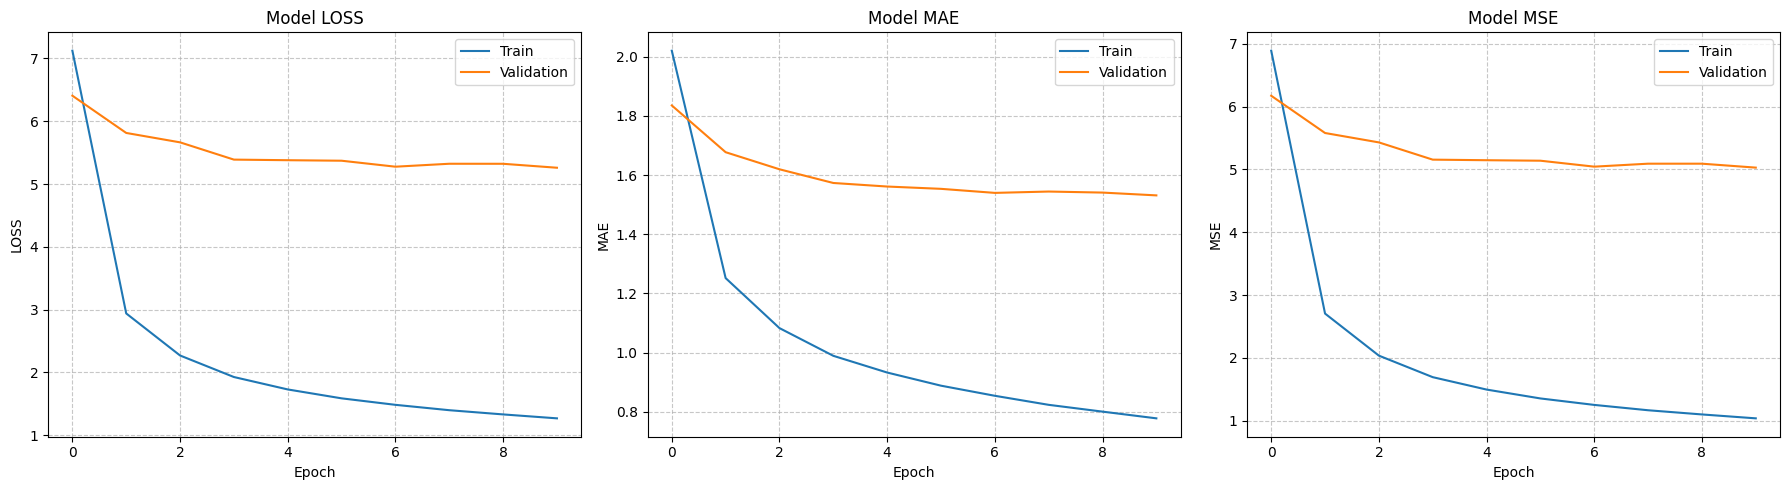


--- Final Test Set Evaluation (GW 31) ---

Evaluating test set performance...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Evaluating test set performance...{'loss': 1.6723463535308838, 'mae': 0.9594168066978455, 'mse': 1.441753625869751}
R²: 0.7232435529208077
MAE: 0.9594168066978455
MSE: 1.4417536258697510
Loss: 1.6723463535308838

Generating Predictions...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

--- Results for Gameweek 31 ---
 Gameweek                     Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       31                Cole Palmer       16.0         13.67       0.18      0.88
       31             Alexander Isak        9.7          8.47       0.24     -0.12
       31                 Phil Foden        8.8          8.39       1.11     -1.39
       31        Alexis Mac Allister        9.0          7.20       1.52     -2.16
       31              Son Heung-min        8.3          6.94       0.15     -0.17
       31         Morgan Gibbs-White        7.2          6.83      -0.28   

In [81]:
# Plot History
plot_training_history(history_31)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 31) ---")
test_result_31 = model_31.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model_31, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_result_31}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred_31 = model_31.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df_31 = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred_31,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 31 ---")
print(results_df_31.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


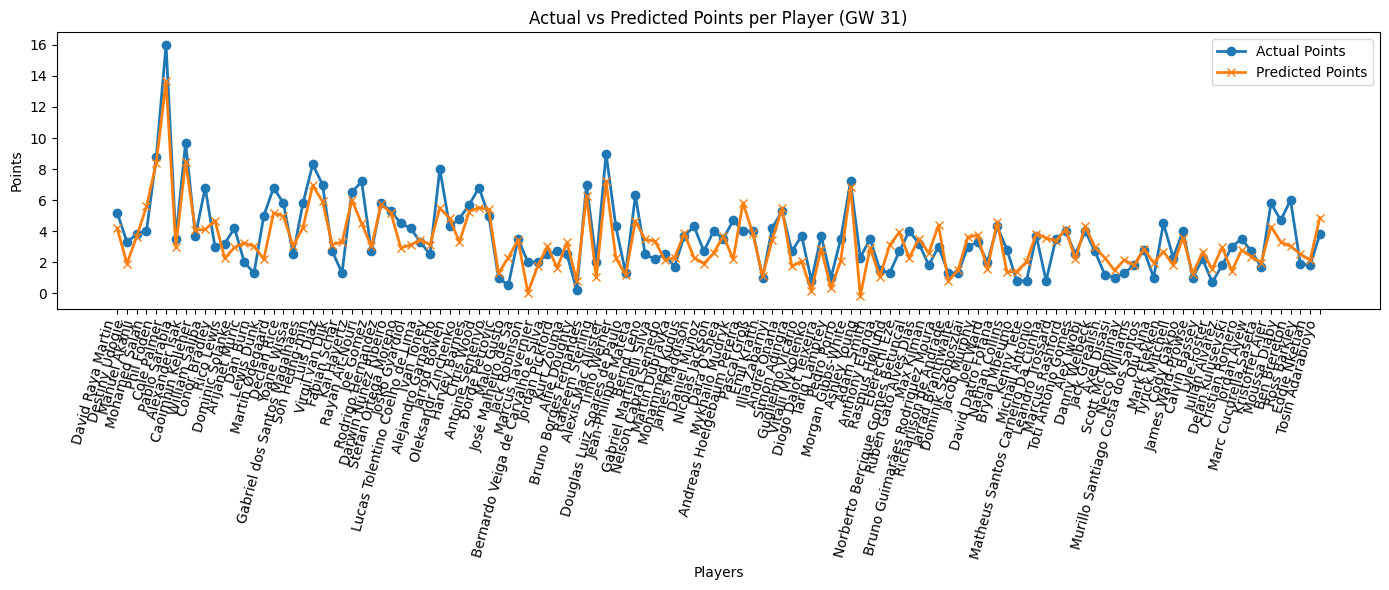

In [82]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred_31, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 31)")
plt.legend()
plt.tight_layout()

plt.show()


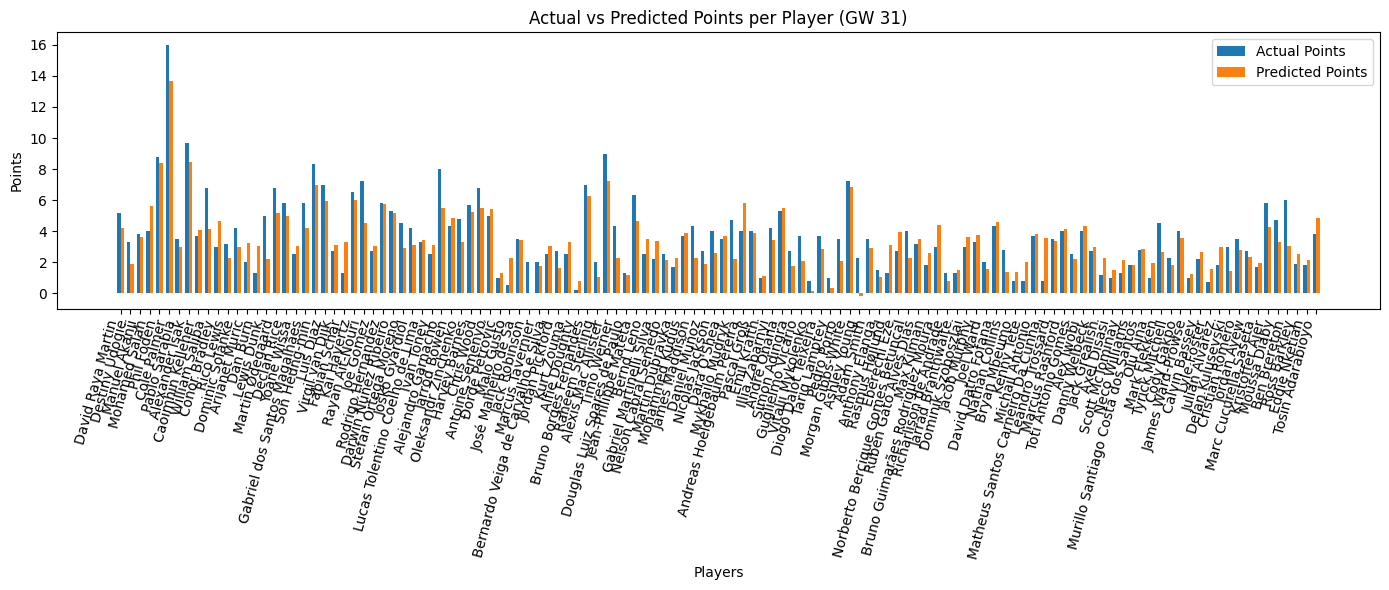

In [83]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred_31, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 31)")
plt.legend()

plt.tight_layout()
plt.show()


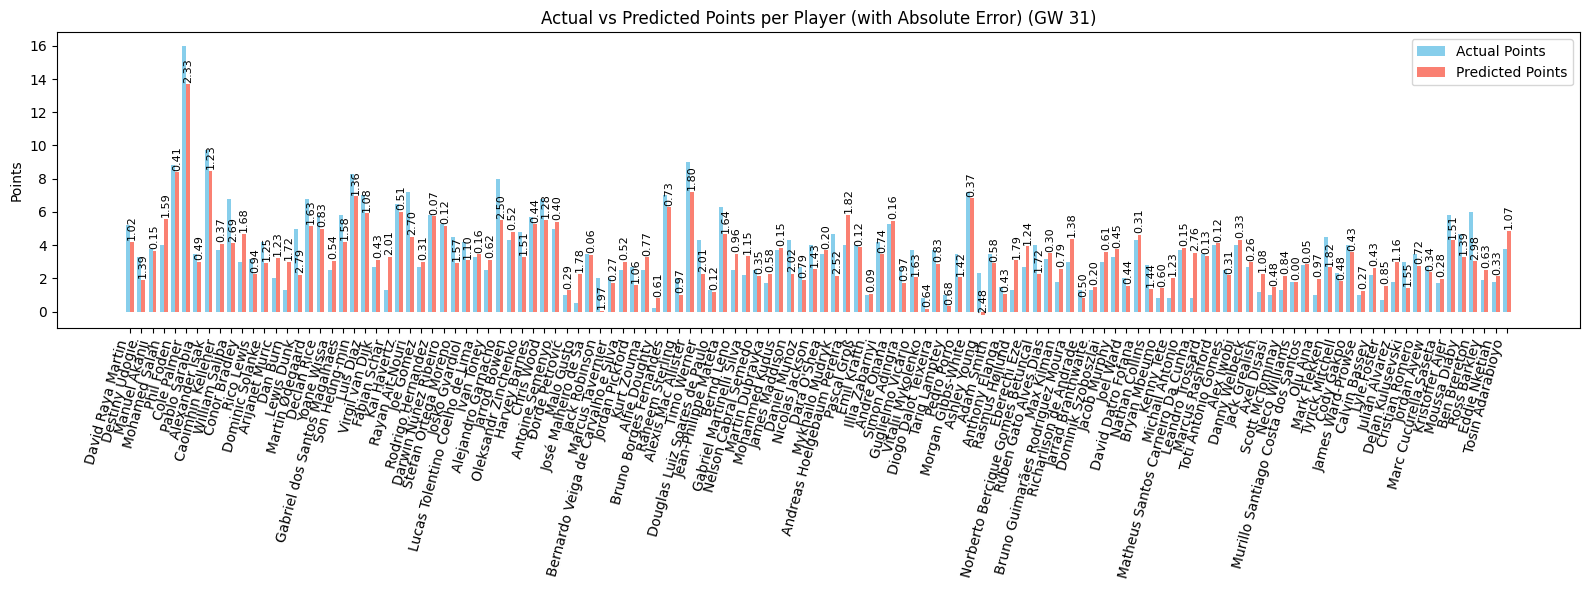

In [84]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred_31)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred_31, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred_31[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error) (GW 31)")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [85]:
curr_data = final_df[final_df['round'] == 31].copy()
curr_data['xP_pred'] = Y_pred_31

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected_31 = run_pipeline(players)

# Get total points
players_selected_31 = curr_data[curr_data['fpl_id'].isin(selected_31['fpl_id'])].copy()
# players_selected_31 = players_selected_31.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_31['xp_rank'] = players_selected_31['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_31['xp_rank'] == 1,  # Highest xp_preds
    players_selected_31['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_31['score'] = players_selected_31['score'] * np.select(conditions, multipliers, default=1.0)
total_points_31 = sum(players_selected_31['score'].values)
print(total_points_31, players_selected_31['score'].values, '--------->', players_selected_31['xP_pred'].values)

players_selected_31[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11


IRL epoch 50/200 loss=-168.2094
IRL epoch 100/200 loss=-1820.7838
IRL epoch 150/200 loss=-7733.5996
IRL epoch 200/200 loss=-21134.7148
HGAT Policy Embeddings Shape: torch.Size([124, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                    name                     team position  price    xP_pred  \
20         Son Heung-min        Tottenham Hotspur      MID   10.1   6.942111   
4             Phil Foden          Manchester City      MID    8.1   8.390673   
5            Cole Palmer                  Chelsea      MID    5.9  13.673321   
50   Alexis Mac Allister                Liverpool      MID    5.8   7.204780   
75    Morgan Gibbs-White        Nottingham Forest      MID    5.7   6.830057   
68           André Onana        Manchester United       GK    4.9   5.461978   
7         Alexander Isak         Newcastle United      FWD    7.7   8.471080   
37            Chris Wood        Nottingham Forest      FWD    4.8   5.517930   
25       Rayan Aït-Nouri  Wolverhampton Wande

,fpl_name,team,position,xP_pred,score
3848,Phil Foden,Manchester City,MID,8.390673,20.0
3849,Cole Palmer,Chelsea,MID,13.673321,40.0
3851,Alexander Isak,Newcastle United,FWD,8.471080,12.0
3854,Conor Bradley,Liverpool,DEF,4.683322,0.0
3864,Son Heung-min,Tottenham Hotspur,MID,6.942111,2.0
3869,Rayan Aït-Nouri,Wolverhampton Wanderers,DEF,4.500615,8.0
3881,Chris Wood,Nottingham Forest,FWD,5.517930,8.0
3894,Alexis Mac Allister,Liverpool,MID,7.204780,10.0
3912,André Onana,Manchester United,GK,5.461978,2.0
3919,Morgan Gibbs-White,Nottingham Forest,MID,6.830057,13.0


##### Rank


In [86]:
fg_managers = fg_managers[fg_managers['gameweek']== 31]
fg_managers[['points']]

position = (fg_managers['points'] > total_points_31).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points_31, total_managers)

print(f"Your predicted player’s total of {total_points_31} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

122.0 217
Your predicted player’s total of 122.0 points would rank:
→ Position: 1 out of 217 managers
→ Percentile: Top 99.54%

Closest scores around you:
   points       prize
0    93.0  R 3,890.25
1    92.5  R 1,695.75
2    89.0  R 1,097.25


### GW 32


#### Predict


In [87]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 32)
X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [88]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model_32 = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model_32.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history_32 = model_32.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10


100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 10.4817 - mae: 2.5680 - mse: 10.2483 - val_loss: 6.0197 - val_mae: 1.7626 - val_mse: 5.7856
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.4260 - mae: 1.3345 - mse: 3.1919 - val_loss: 5.5390 - val_mae: 1.6392 - val_mse: 5.3051
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.6209 - mae: 1.1492 - mse: 2.3871 - val_loss: 5.1981 - val_mae: 1.5610 - val_mse: 4.9644
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.1155 - mae: 1.0258 - mse: 1.8819 - val_loss: 4.9705 - val_mae: 1.5270 - val_mse: 4.7370
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8390 - mae: 0.9553 - mse: 1.6056 - val_loss: 4.8733 - val_mae: 1.4966 - val_mse: 4.6400
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.8349 - mae: 0.9497 - mse: 1.6016 - val_loss: 4.8716 - val_mae: 1.4775 - val_mse: 4.6385
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.5189 - mae: 0.8607 - mse: 1.2859 - val_loss: 4.

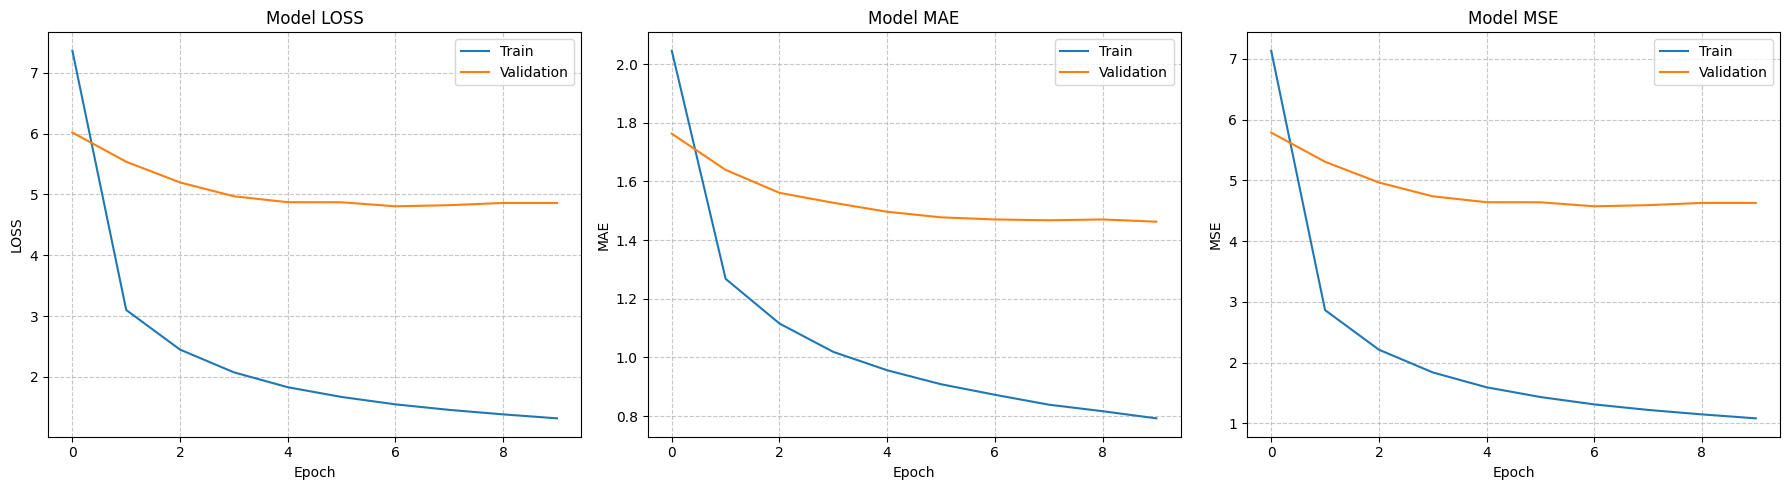


--- Final Test Set Evaluation (GW 32) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Evaluating test set performance...{'loss': 1.0963102579116821, 'mae': 0.746239185333252, 'mse': 0.8635117411613464}
R²: 0.7659926371357992
MAE: 0.7462391853332520
MSE: 0.8635117411613464
Loss: 1.0963102579116821

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

--- Results for Gameweek 32 ---
 Gameweek                       Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       32                  Cole Palmer       13.7         14.00      -2.09     -1.16
       32                  Kai Havertz        8.2          8.40       0.70     -0.69
       32              Kevin De Bruyne        7.8          8.39       1.22     -1.35
       32            Rodrigo Hernandez        6.2          6.99       1.22     -1.35
       32           Morgan Gibbs-White        5.5          6.51      -2.08      1.56
       32 Gabriel dos Santos Magalhães        5.8          6.38

In [89]:
# Plot History
plot_training_history(history_32)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 32) ---")
test_result_32 = model_32.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model_32, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_result_32}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred_32 = model_32.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df_32 = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred_32,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 32 ---")
print(results_df_32.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


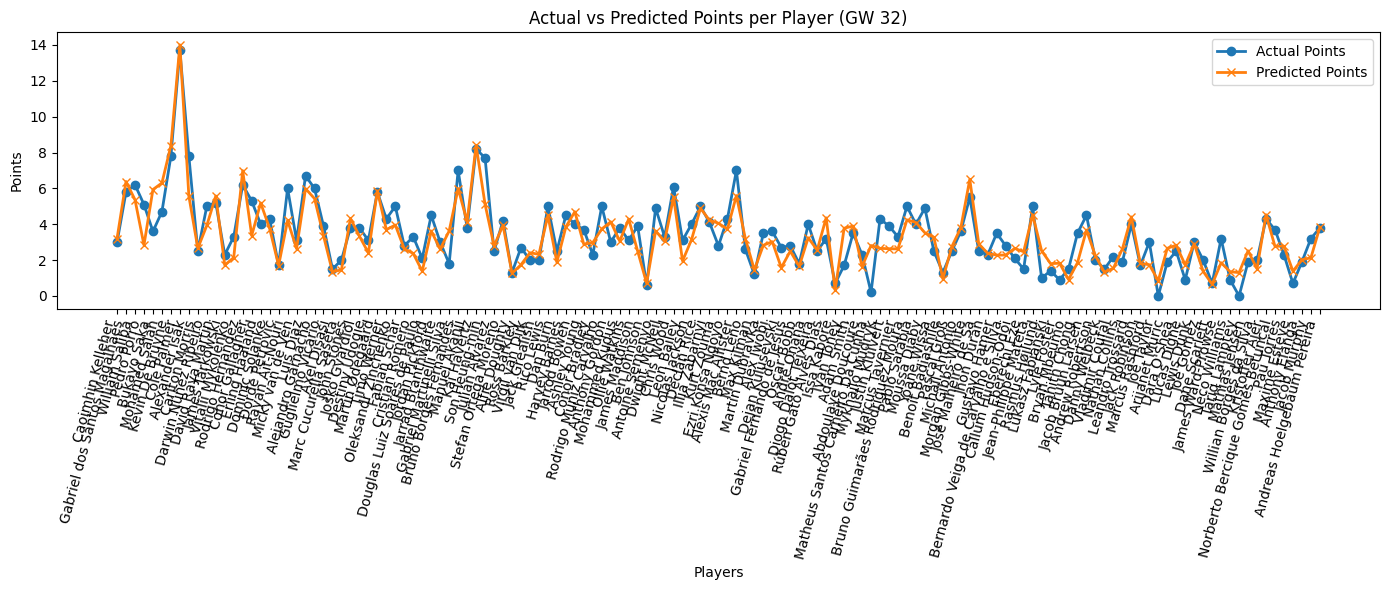

In [90]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred_32, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 32)")
plt.legend()
plt.tight_layout()

plt.show()


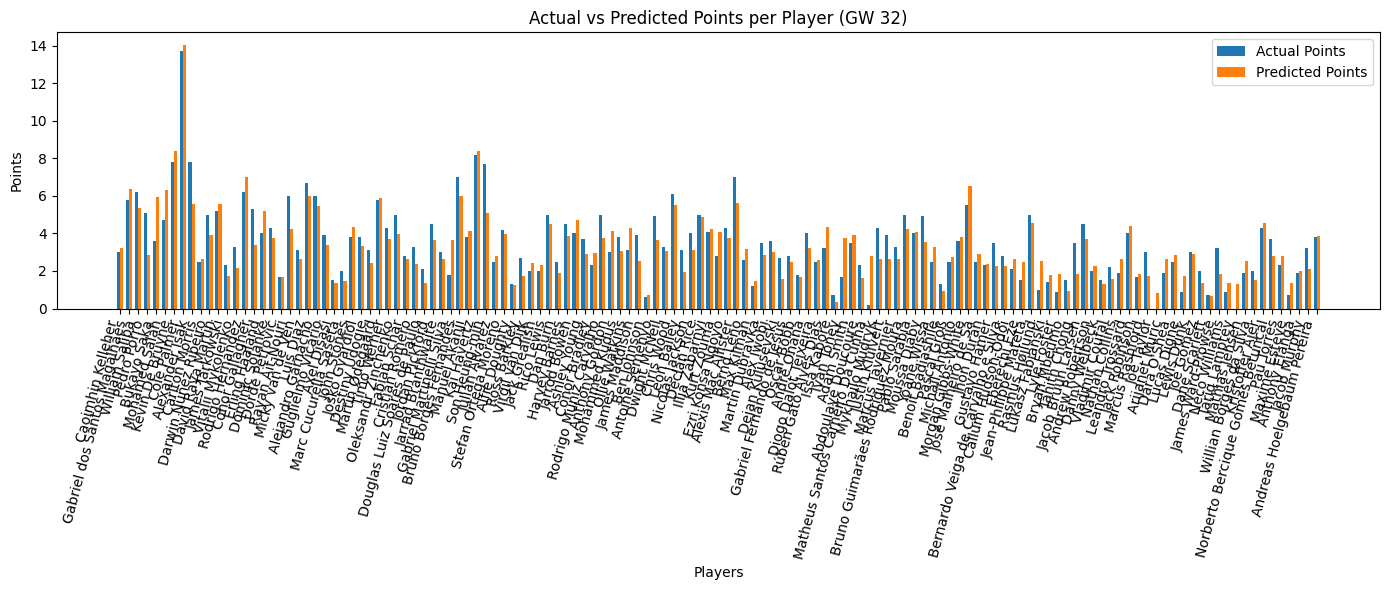

In [91]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred_32, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 32)")
plt.legend()

plt.tight_layout()
plt.show()


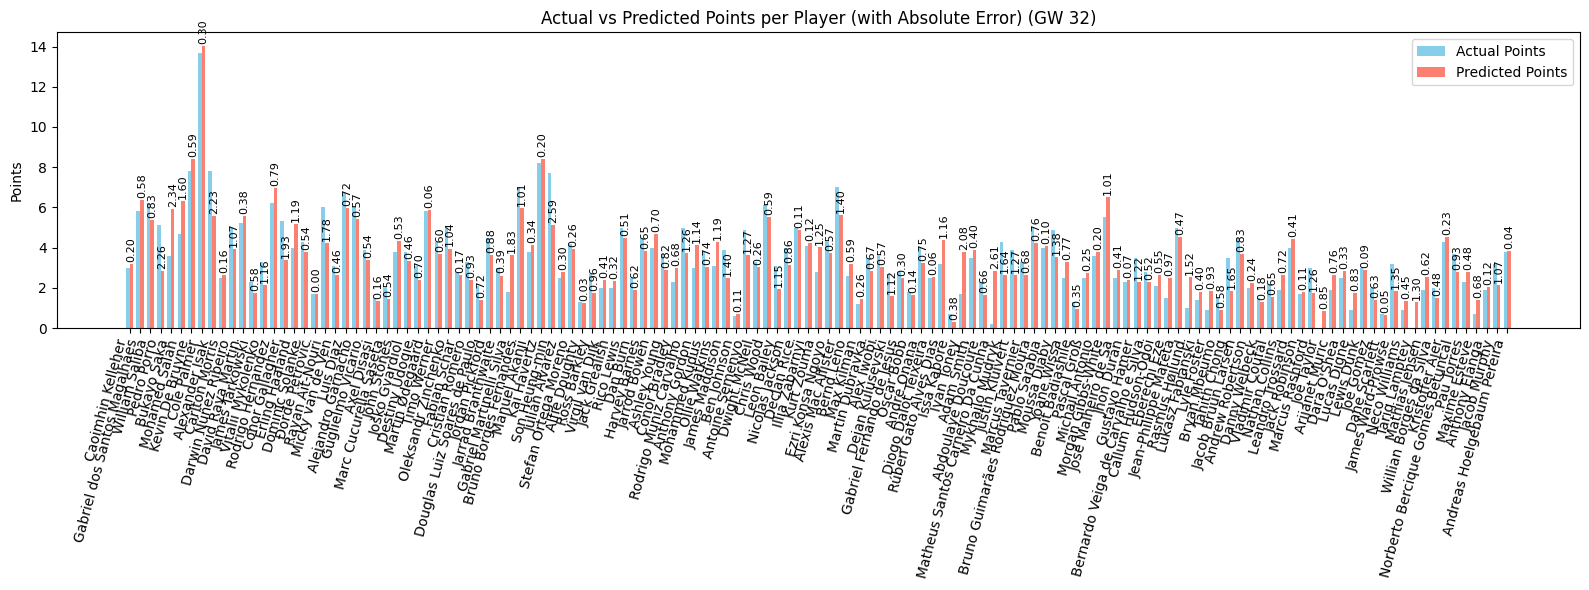

In [92]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred_32)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred_32, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred_32[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error) (GW 32)")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [93]:
curr_data = final_df[final_df['round'] == 32].copy()
curr_data['xP_pred'] = Y_pred_32

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected_32 = run_pipeline(players)

# Get total points
players_selected_32 = curr_data[curr_data['fpl_id'].isin(selected_32['fpl_id'])].copy()
# players_selected_32 = players_selected_32.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_32['xp_rank'] = players_selected_32['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_32['xp_rank'] == 1,  # Highest xp_preds
    players_selected_32['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_32['score'] = players_selected_32['score'] * np.select(conditions, multipliers, default=1.0)
total_points_32 = sum(players_selected_32['score'].values)
print(total_points_32, players_selected_32['score'].values, '--------->', players_selected_32['xP_pred'].values)

players_selected_32[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-412.8396
IRL epoch 100/200 loss=-4658.8140
IRL epoch 150/200 loss=-20032.3906
IRL epoch 200/200 loss=-55095.2734
HGAT Policy Embeddings Shape: torch.Size([135, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                             name               team position  price  \
5                   Mohamed Salah          Liverpool      MID   13.4   
6                 Kevin De Bruyne    Manchester City      MID   10.3   
40                    Kai Havertz            Arsenal      MID    7.3   
7                     Cole Palmer            Chelsea      MID    6.0   
14              Rodrigo Hernandez    Manchester City      MID    5.6   
11              David Raya Martin            Arsenal       GK    5.1   
8                  Alexander Isak   Newcastle United      FWD    7.9   
62                     Chris Wood  Nottingham Forest      FWD    4.8   
1    Gabriel dos Santos Magalhães            Arsenal      DEF    5.3   

,fpl_name,team,position,xP_pred,score
3969,Gabriel dos Santos Magalhães,Arsenal,DEF,6.383251,6.0
3973,Mohamed Salah,Liverpool,MID,6.301270,8.0
3974,Kevin De Bruyne,Manchester City,MID,8.385234,18.0
3975,Cole Palmer,Chelsea,MID,14.004334,10.0
3976,Alexander Isak,Newcastle United,FWD,5.573661,2.0
3979,David Raya Martin,Arsenal,GK,5.577145,6.0
3982,Rodrigo Hernandez,Manchester City,MID,6.986792,5.0
4008,Kai Havertz,Arsenal,MID,8.404624,21.0
4016,Rico Lewis,Manchester City,DEF,4.487967,8.0
4030,Chris Wood,Nottingham Forest,FWD,5.512894,6.0


##### Rank


In [94]:
fg_managers = fg_managers[fg_managers['gameweek']== 32]
fg_managers[['points']]

position = (fg_managers['points'] > total_points_32).sum() + 1
# 4. Display result
total_managers = len(fg_managers)
percentile = 100 * (1-(position / total_managers))

print(total_points_32, total_managers)

print(f"Your predicted player’s total of {total_points_32} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

91.0 0
Your predicted player’s total of 91.0 points would rank:
→ Position: 1 out of 0 managers
→ Percentile: Top -inf%

Closest scores around you:
Empty DataFrame
Columns: [points, prize]
Index: []


/tmp/ipython-input-2431715187.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  percentile = 100 * (1-(position / total_managers))


### GW 33


#### Predict


In [95]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 33)
X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [96]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model_33 = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model_33.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history_33 = model_33.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 10.8506 - mae: 2.5232 - mse: 10.6175 - val_loss: 4.9735 - val_mae: 1.6326 - val_mse: 4.7399
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.8776 - mae: 1.4322 - mse: 3.6440 - val_loss: 4.6170 - val_mae: 1.4995 - val_mse: 4.3835
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.7881 - mae: 1.2093 - mse: 2.5547 - val_loss: 4.2679 - val_mae: 1.4205 - val_mse: 4.0346
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2283 - mae: 1.0660 - mse: 1.9950 - val_loss: 4.2583 - val_mae: 1.3963 - val_mse: 4.0251
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0547 - mae: 1.0164 - mse: 1.8216 - val_loss: 4.1609 - val_mae: 1.3752 - val_mse: 3.9280
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7663 - mae: 0.9251 - mse: 1.5335 - val_loss: 4.1711 - val_mae: 1.3689 - val_mse: 3.9386
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6135 - mae: 0

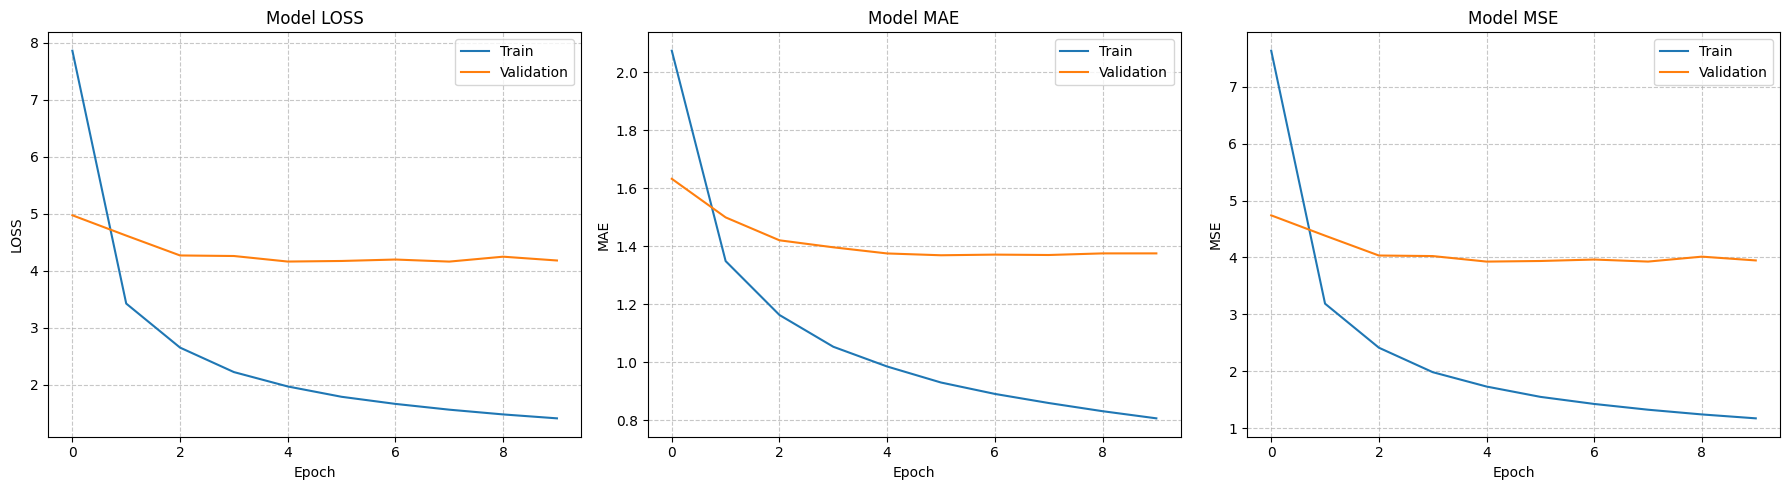


--- Final Test Set Evaluation (GW 33) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Evaluating test set performance...{'loss': 2.1047956943511963, 'mae': 1.0097589492797852, 'mse': 1.8729661703109741}
R²: 0.5546247531261103
MAE: 1.0097589492797852
MSE: 1.8729661703109741
Loss: 2.1047956943511963

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Results for Gameweek 33 ---
 Gameweek                     Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       33                Cole Palmer       16.5         14.22       0.58      1.23
       33            Kevin De Bruyne        7.3         11.37       1.50     -2.09
       33     Bruno Borges Fernandes        8.5          8.36      -0.45      0.46
       33 Andreas Hoelgebaum Pereira        7.2          7.39      -0.48      0.59
       33                Kai Havertz        6.3          7.11       1.24     -1.45
       33                Jérémy Doku        7.3          6.75       1.50  

In [97]:
# Plot History
plot_training_history(history_33)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 33) ---")
test_result_33 = model_33.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model_33, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_result_33}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred_33 = model_33.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df_33 = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred_33,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 33 ---")
print(results_df_33.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


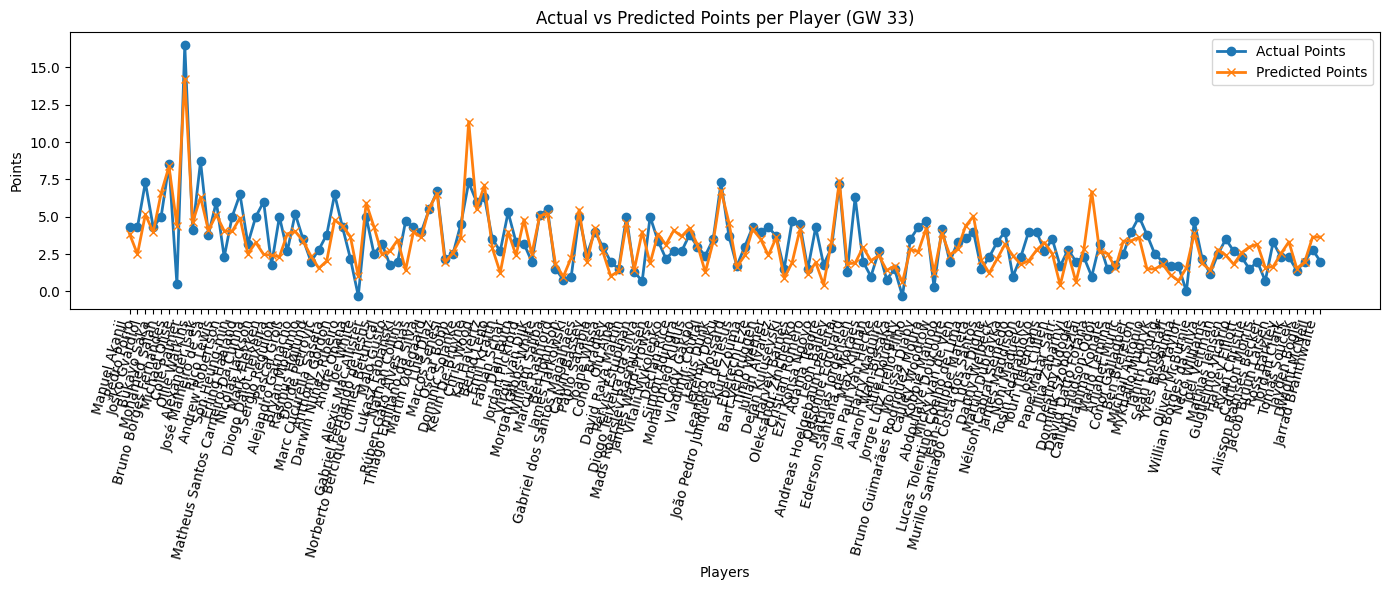

In [98]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred_33, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 33)")
plt.legend()
plt.tight_layout()

plt.show()


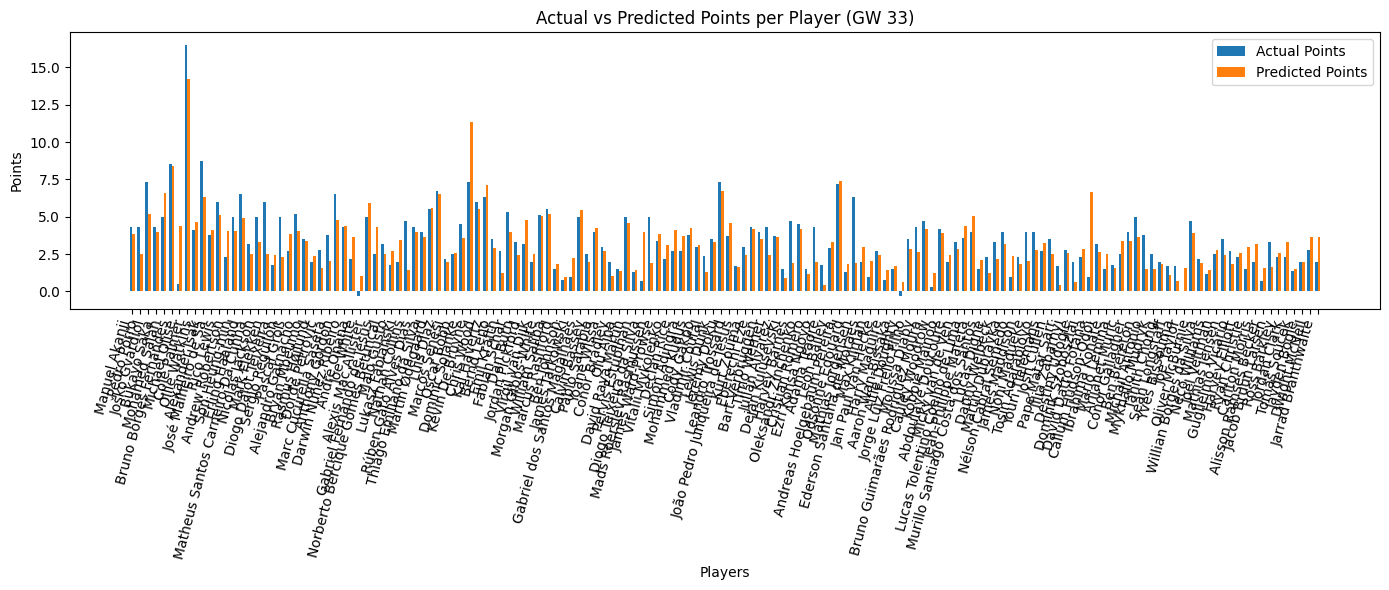

In [99]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred_33, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 33)")
plt.legend()

plt.tight_layout()
plt.show()


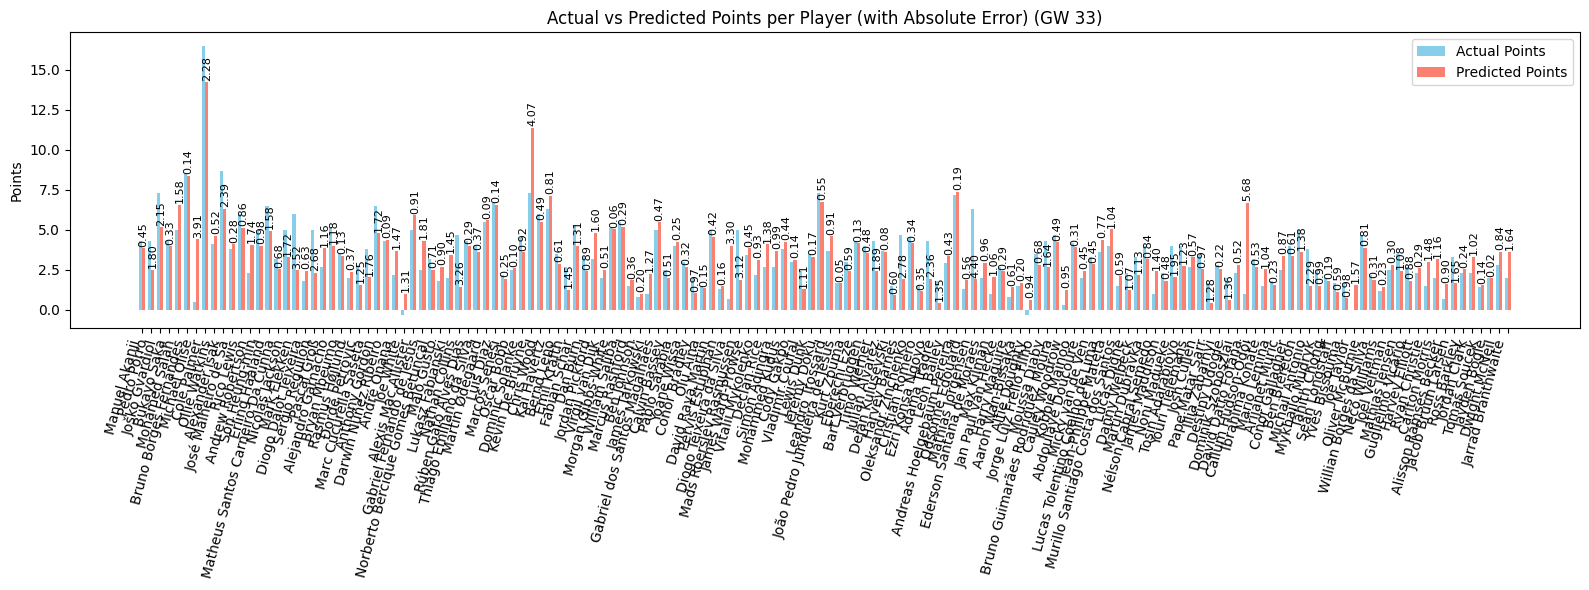

In [100]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred_33)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred_33, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred_33[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error) (GW 33)")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [101]:
curr_data = final_df[final_df['round'] == 33].copy()
curr_data['xP_pred'] = Y_pred_33

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected_33 = run_pipeline(players)

# Get total points
players_selected_33 = curr_data[curr_data['fpl_id'].isin(selected_33['fpl_id'])].copy()
# players_selected_33 = players_selected_33.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_33['xp_rank'] = players_selected_33['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_33['xp_rank'] == 1,  # Highest xp_preds
    players_selected_33['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_33['score'] = players_selected_33['score'] * np.select(conditions, multipliers, default=1.0)
total_points_33 = sum(players_selected_33['score'].values)
print(total_points_33, players_selected_33['score'].values, '--------->', players_selected_33['xP_pred'].values)

players_selected_33[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-314.9662
IRL epoch 100/200 loss=-3519.4448
IRL epoch 150/200 loss=-15095.8359
IRL epoch 200/200 loss=-41479.5352
HGAT Policy Embeddings Shape: torch.Size([152, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                             name               team position  price  \
43                Kevin De Bruyne    Manchester City      MID   10.4   
5          Bruno Borges Fernandes  Manchester United      MID    8.2   
45                    Kai Havertz            Arsenal      MID    7.4   
7                     Cole Palmer            Chelsea      MID    6.1   
90     Andreas Hoelgebaum Pereira             Fulham      MID    5.3   
50                Jordan Pickford            Everton       GK    4.7   
9                  Alexander Isak   Newcastle United      FWD    7.9   
122            David Datro Fofana            Chelsea      FWD    5.0   
53                 William Saliba            Arsenal      DEF    5.9   

,fpl_name,team,position,xP_pred,score
4105,Joško Gvardiol,Manchester City,DEF,5.154136,12.0
4108,Bruno Borges Fernandes,Manchester United,MID,8.364180,15.0
4110,Cole Palmer,Chelsea,MID,14.216564,52.0
4112,Alexander Isak,Newcastle United,FWD,6.309541,12.0
4146,Kevin De Bruyne,Manchester City,MID,11.373460,3.0
4148,Kai Havertz,Arsenal,MID,7.114306,1.0
4153,Jordan Pickford,Everton,GK,4.803437,0.0
4156,William Saliba,Arsenal,DEF,5.206438,1.0
4160,Gabriel dos Santos Magalhães,Arsenal,DEF,5.467253,0.0
4193,Andreas Hoelgebaum Pereira,Fulham,MID,7.386065,15.0


##### Rank


In [102]:
fg_managers_33 = fg_managers[fg_managers['gameweek']== 33]
fg_managers_33[['points']]

position = (fg_managers_33['points'] > total_points_33).sum() + 1
# 4. Display result
total_managers = len(fg_managers_33)
percentile = 100 * (1-(position / total_managers))

print(total_points_33, total_managers)

print(f"Your predicted player’s total of {total_points_33} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers_33.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

113.0 0
Your predicted player’s total of 113.0 points would rank:
→ Position: 1 out of 0 managers
→ Percentile: Top -inf%

Closest scores around you:
Empty DataFrame
Columns: [points, prize]
Index: []


/tmp/ipython-input-2909032027.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  percentile = 100 * (1-(position / total_managers))


### GW 34


#### Predict


In [103]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 34)
X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)


In [104]:
# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model_34 = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model_34.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history_34 = model_34.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Starting Training...
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 11.7433 - mae: 2.6658 - mse: 11.5104 - val_loss: 3.3553 - val_mae: 1.3118 - val_mse: 3.1217
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.4338 - mae: 1.3539 - mse: 3.2002 - val_loss: 2.7106 - val_mae: 1.1693 - val_mse: 2.4772
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.8357 - mae: 1.1865 - mse: 2.6023 - val_loss: 2.3671 - val_mae: 1.0911 - val_mse: 2.1338
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4756 - mae: 1.1174 - mse: 2.2424 - val_loss: 2.2546 - val_mae: 1.0638 - val_mse: 2.0214
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.2449 - mae: 1.0558 - mse: 2.0117 - val_loss: 2.1443 - val_mae: 1.0378 - val_mse: 1.9112
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.0726 - mae: 1.0055 - mse: 1.8397 - val_loss: 2.0955 - val_mae: 1.0235 - val_mse: 1.8626
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0236 - mae: 0.

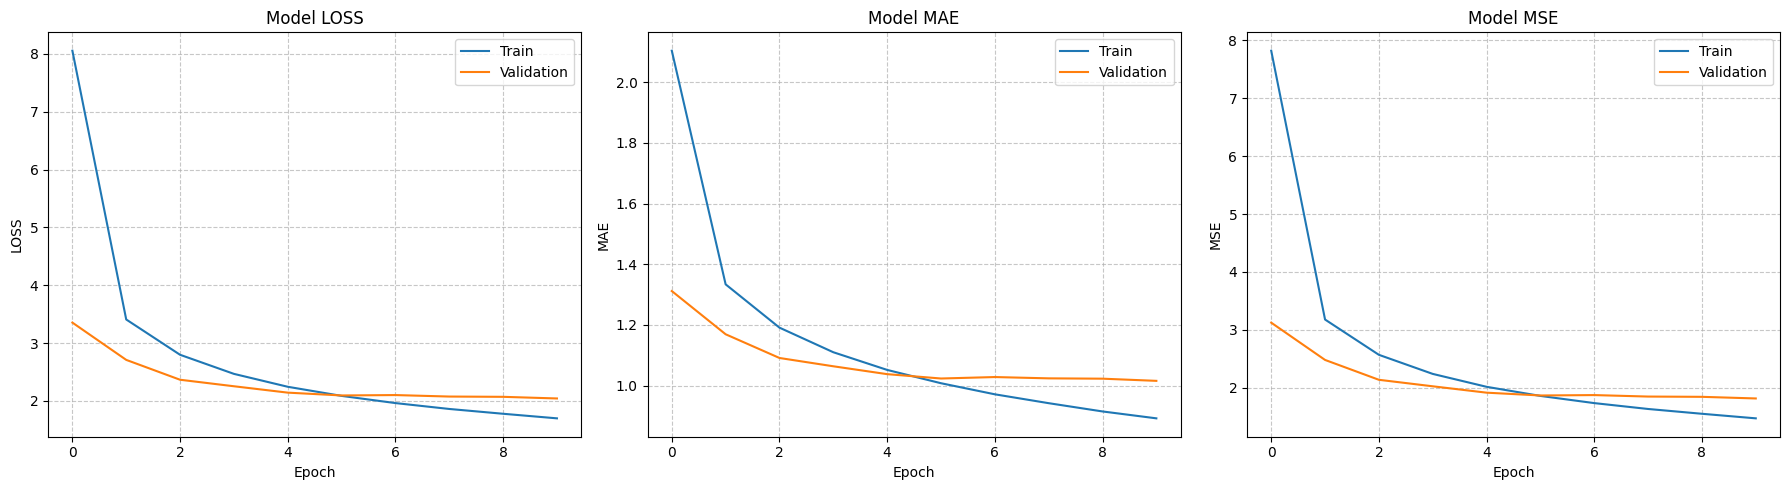


--- Final Test Set Evaluation (GW 34) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Evaluating test set performance...{'loss': 7.333439826965332, 'mae': 1.8109519481658936, 'mse': 7.101093769073486}
R²: 0.3347085181641010
MAE: 1.8109519481658936
MSE: 7.1010937690734863
Loss: 7.3334398269653320

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Results for Gameweek 34 ---
 Gameweek                 Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       34 Bruno Borges Fernandes       10.9         13.75       1.06     -1.39
       34             Phil Foden        8.8         11.05       0.96     -1.09
       34            Kai Havertz       15.4          9.16       0.88     -1.02
       34        Kevin De Bruyne        7.4          7.58       0.96     -1.09
       34        Martin Ødegaard       15.4          7.47       0.88     -1.02
       34         Alexander Isak        7.8          6.53      -0.15      0.31
       34   Jean-Phil

In [105]:
# Plot History
plot_training_history(history_34)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 34) ---")
test_result_34 = model_34.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model_34, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_result_34}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred_34 = model_34.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df_34 = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred_34,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 34 ---")
print(results_df_34.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


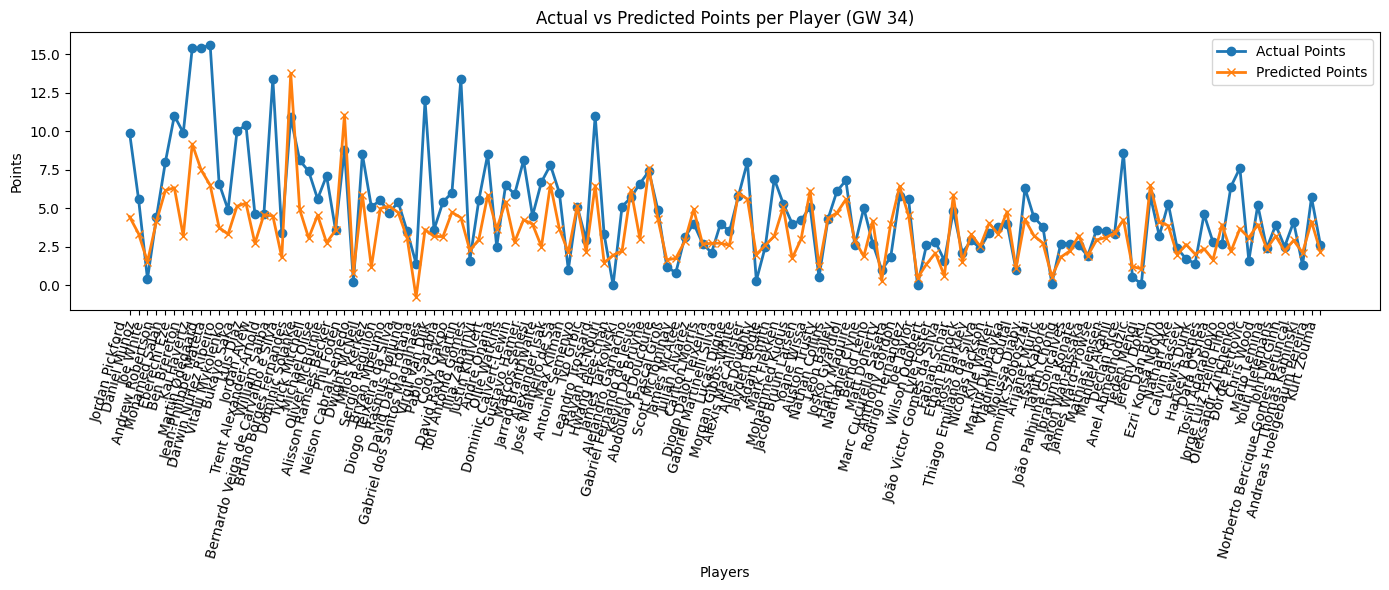

In [106]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred_34, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 34)")
plt.legend()
plt.tight_layout()

plt.show()


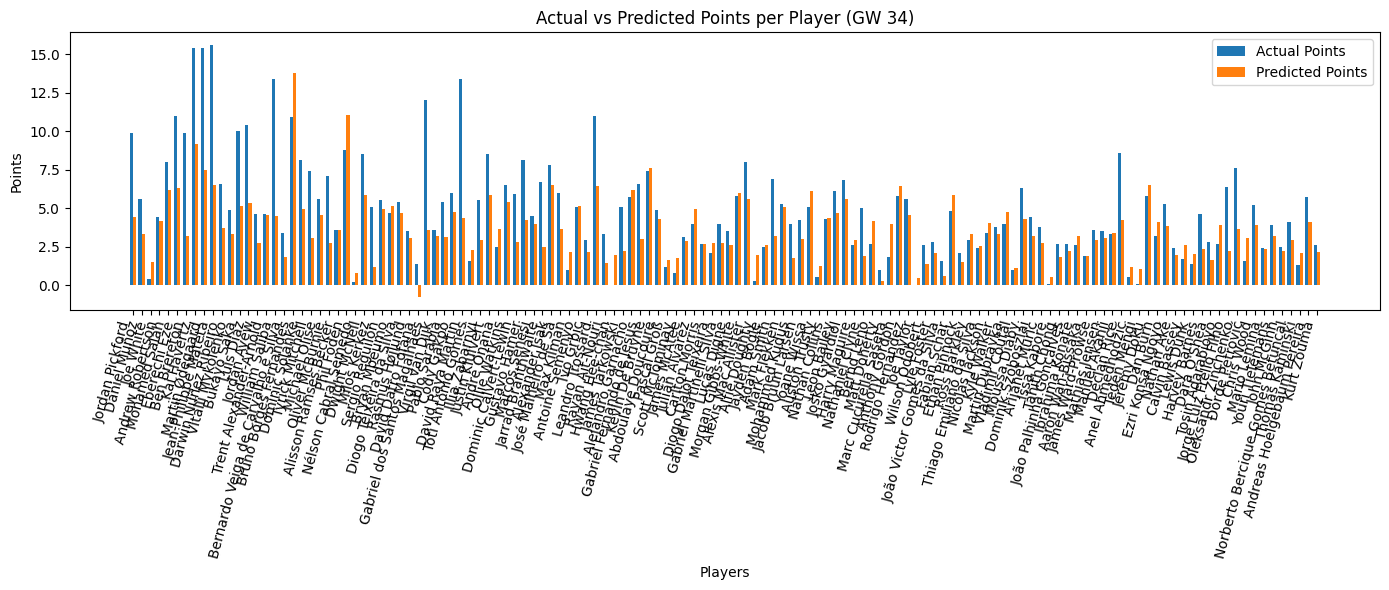

In [107]:
# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred_34, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 34)")
plt.legend()

plt.tight_layout()
plt.show()


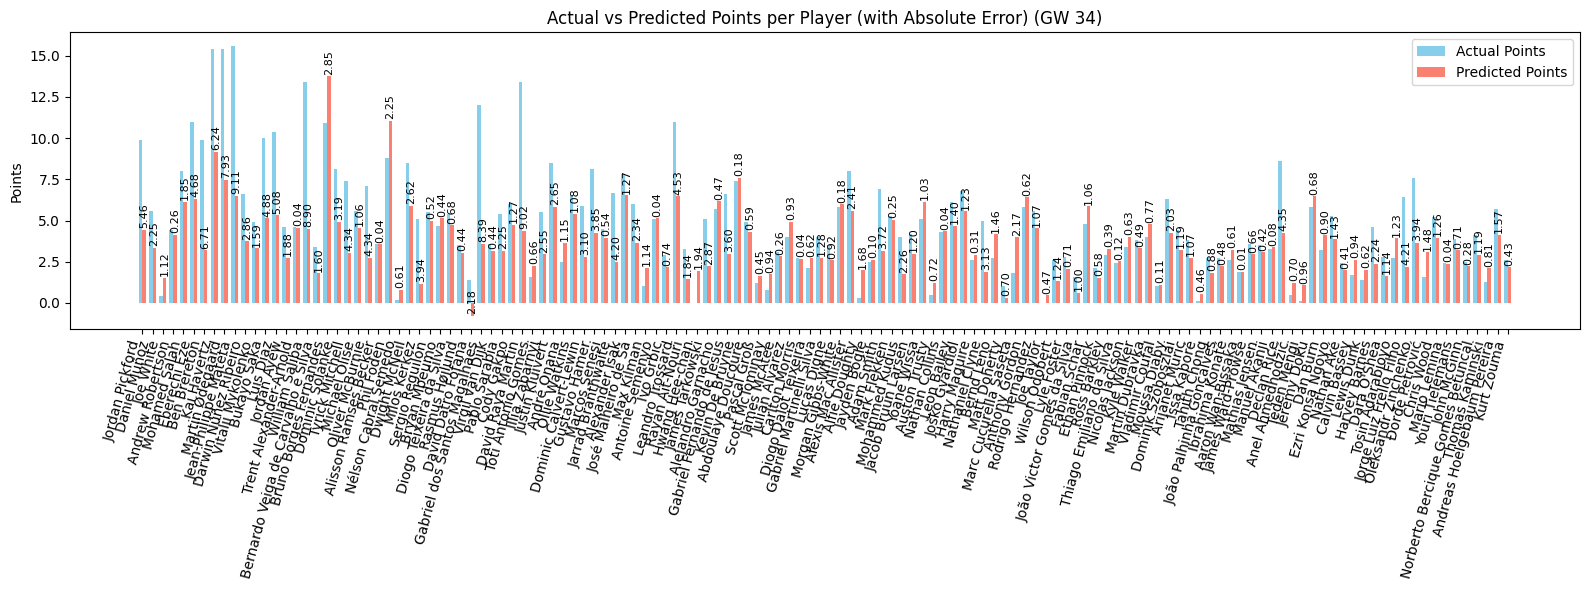

In [108]:
# Calculate absolute errors
errors = np.abs(Y_test - Y_pred_34)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred_34, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred_34[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error) (GW 34)")
plt.legend()
plt.tight_layout()

plt.show()


#### Optimize


In [109]:
curr_data = final_df[final_df['round'] == 34].copy()
curr_data['xP_pred'] = Y_pred_34

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected_34 = run_pipeline(players)

# Get total points
players_selected_34 = curr_data[curr_data['fpl_id'].isin(selected_34['fpl_id'])].copy()
# players_selected_34 = players_selected_34.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_34['xp_rank'] = players_selected_34['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_34['xp_rank'] == 1,  # Highest xp_preds
    players_selected_34['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_34['score'] = players_selected_34['score'] * np.select(conditions, multipliers, default=1.0)
total_points_34 = sum(players_selected_34['score'].values)
print(total_points_34, players_selected_34['score'].values, '--------->', players_selected_34['xP_pred'].values)

players_selected_34[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-264.0143
IRL epoch 100/200 loss=-2779.9619
IRL epoch 150/200 loss=-11691.0361
IRL epoch 200/200 loss=-31847.6406
HGAT Policy Embeddings Shape: torch.Size([134, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                      name               team position  price    xP_pred  \
58         Kevin De Bruyne    Manchester City      MID   10.4   7.581361   
8          Martin Ødegaard            Arsenal      MID    8.6   7.473241   
18  Bruno Borges Fernandes  Manchester United      MID    8.3  13.752068   
24              Phil Foden    Manchester City      MID    8.2  11.051099   
7              Kai Havertz            Arsenal      MID    7.4   9.161730   
73            Mark Flekken          Brentford       GK    4.7   5.051698   
47          Alexander Isak   Newcastle United      FWD    8.0   6.534167   
9     Jean-Philippe Mateta     Crystal Palace      FWD    5.0   6.492883   
92            Fabian Schär   Newcas

,fpl_name,team,position,xP_pred,score
4262,Kai Havertz,Arsenal,MID,9.161730,17.0
4263,Martin Ødegaard,Arsenal,MID,7.473241,20.0
4264,Jean-Philippe Mateta,Crystal Palace,FWD,6.492883,29.0
4273,Bruno Borges Fernandes,Manchester United,MID,13.752068,36.0
4279,Phil Foden,Manchester City,MID,11.051099,24.0
4283,Sergio Reguilón,Manchester United,DEF,4.977644,7.0
4302,Alexander Isak,Newcastle United,FWD,6.534167,2.0
4313,Kevin De Bruyne,Manchester City,MID,7.581361,9.0
4328,Mark Flekken,Brentford,GK,5.051698,2.0
4335,Joško Gvardiol,Manchester City,DEF,5.568058,6.0


##### Rank


In [110]:
fg_managers_34 = fg_managers[fg_managers['gameweek']== 34]
fg_managers_34[['points']]

position = (fg_managers_34['points'] > total_points_34).sum() + 1
# 4. Display result
total_managers = len(fg_managers_34)
percentile = 100 * (1-(position / total_managers))

print(total_points_34, total_managers)

print(f"Your predicted player’s total of {total_points_34} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers_34.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

153.0 0
Your predicted player’s total of 153.0 points would rank:
→ Position: 1 out of 0 managers
→ Percentile: Top -inf%

Closest scores around you:
Empty DataFrame
Columns: [points, prize]
Index: []


/tmp/ipython-input-1328160787.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  percentile = 100 * (1-(position / total_managers))


### GW 35


#### Predict


Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)

Starting Training...
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 24.4948 - mae: 4.2605 - mse: 24.2621 - val_loss: 7.8165 - val_mae: 2.1135 - val_mse: 7.5834
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.8927 - mae: 1.6410 - mse: 4.6593 - val_loss: 4.1842 - val_mae: 1.4329 - val_mse: 3.9506
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3.3821 - mae: 1.3133 - mse: 3.1486 - val_loss: 3.6257 - val_mae: 1.3064 - val_mse: 3.3924
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.9282 - mae: 1.2053 - mse: 2.6950 - val_loss: 3.3031 - val_mae: 1.2314 - val_mse: 3.0702
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.4684 - mae: 1.0934 - mse: 2.2355 - val_loss: 3.1604 - val_mae: 1.1955 - val_mse: 2.9279
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.3892 - mae: 1.0552 - mse: 2.1567 - val_loss: 2.9297 - val_mae: 1.1410 - val_mse: 2.6974


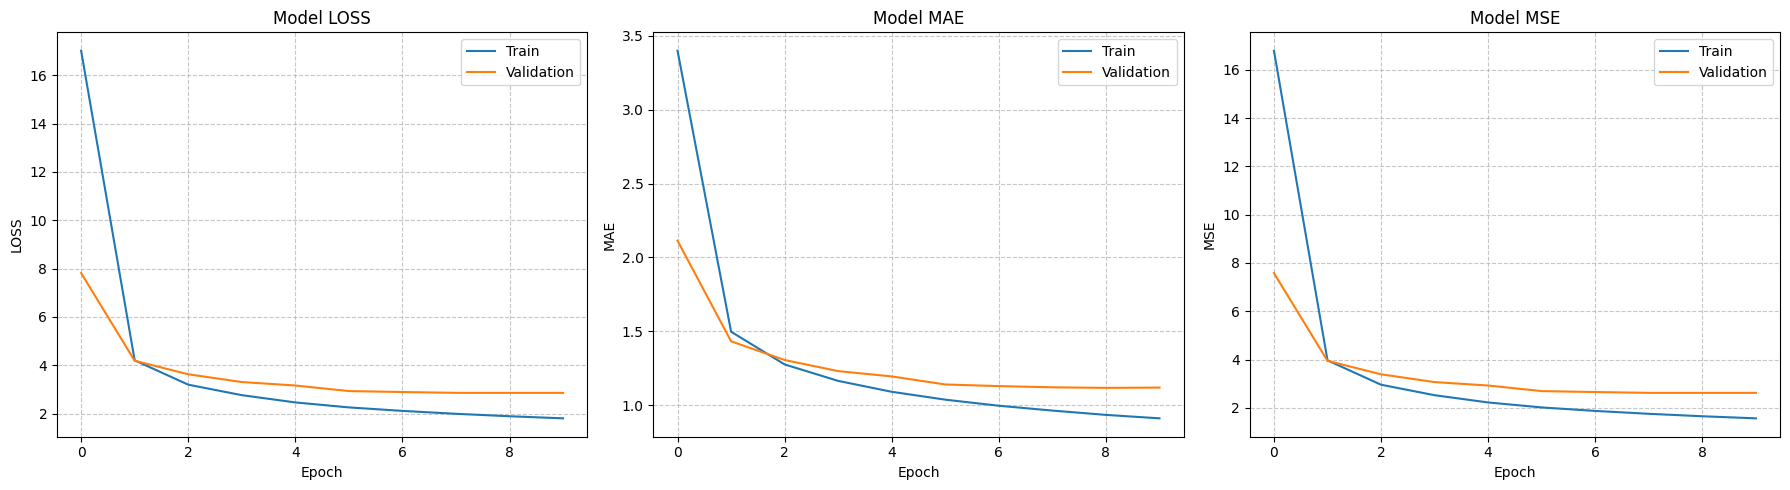


--- Final Test Set Evaluation (GW 35) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Evaluating test set performance...{'loss': 2.7253012657165527, 'mae': 1.1121028661727905, 'mse': 2.494074583053589}
R²: 0.6078970478777908
MAE: 1.1121028661727905
MSE: 2.4940745830535889
Loss: 2.7253012657165527

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

--- Results for Gameweek 35 ---
 Gameweek                          Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       35          Bruno Borges Fernandes       11.3         14.29       0.81     -0.89
       35                     Cole Palmer       18.6         13.16       0.01      0.71
       35                     Kai Havertz        8.8         10.03       0.50     -0.47
       35            Jean-Philippe Mateta        7.6         10.02      -0.77      0.92
       35                  Alexander Isak        7.7          9.48       1.29     -1.65
       35                 Kevin De Bruyne    

In [111]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 35)
X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model_35 = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model_35.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history_35 = model_35.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Plot History
plot_training_history(history_35)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 35) ---")
test_result_35 = model_35.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model_35, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_result_35}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred_35 = model_35.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df_35 = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred_35,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 35 ---")
print(results_df_35.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


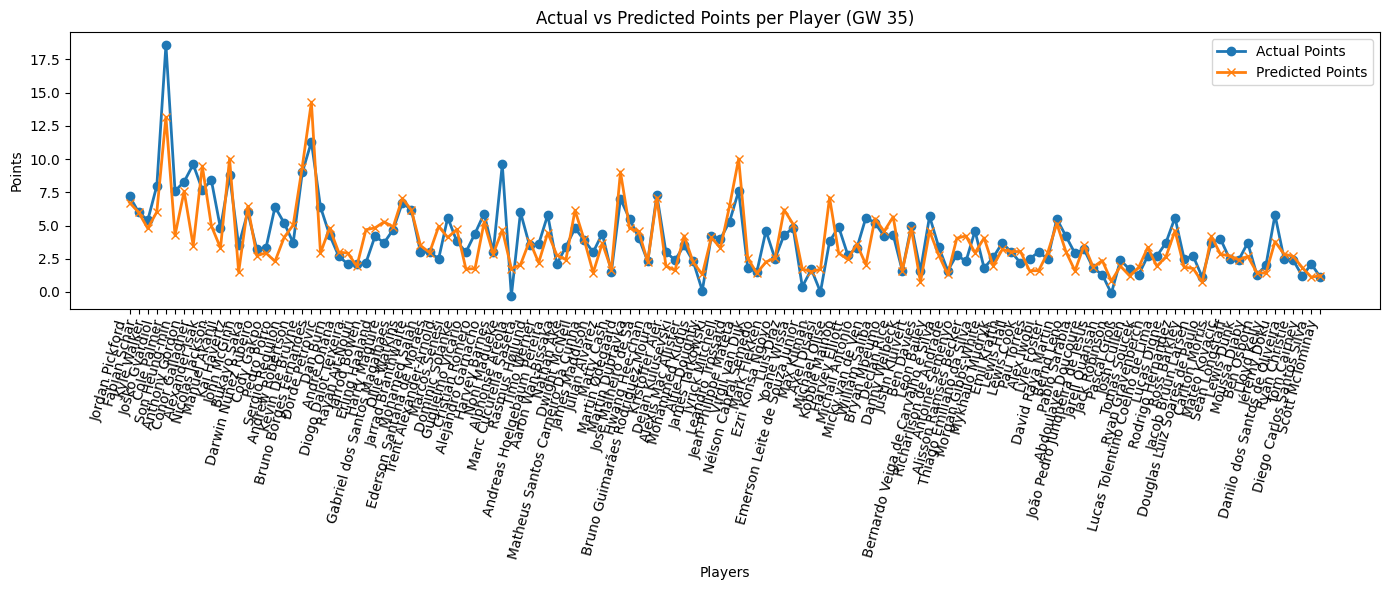

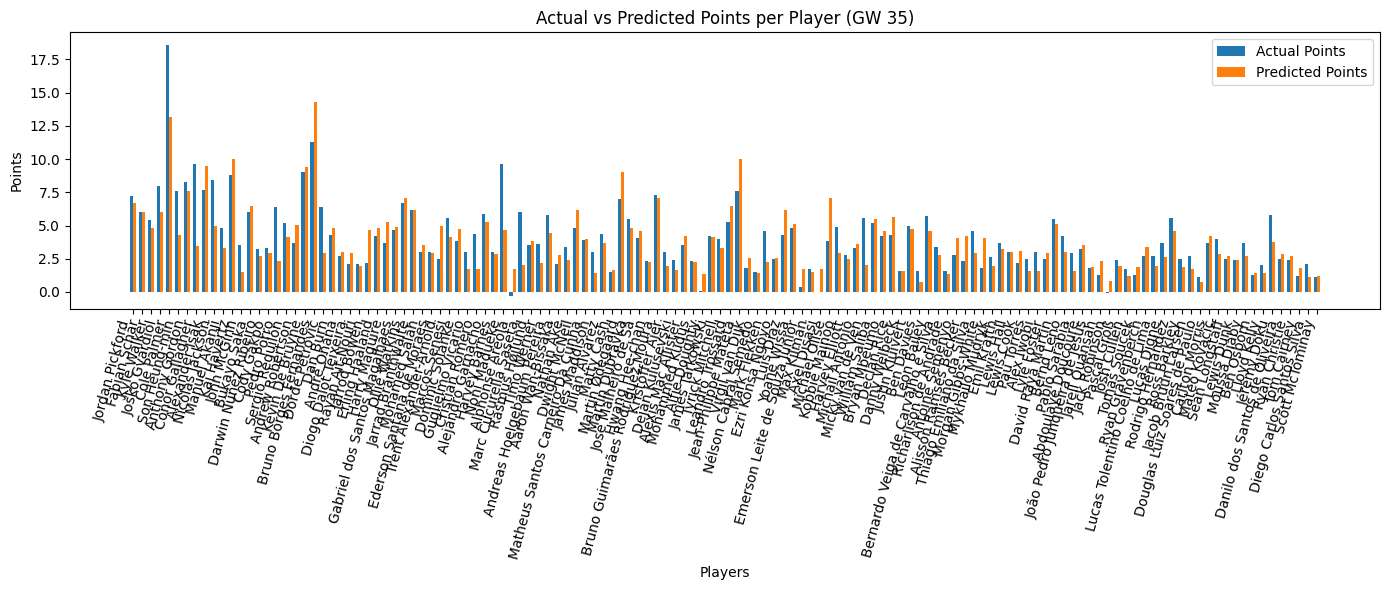

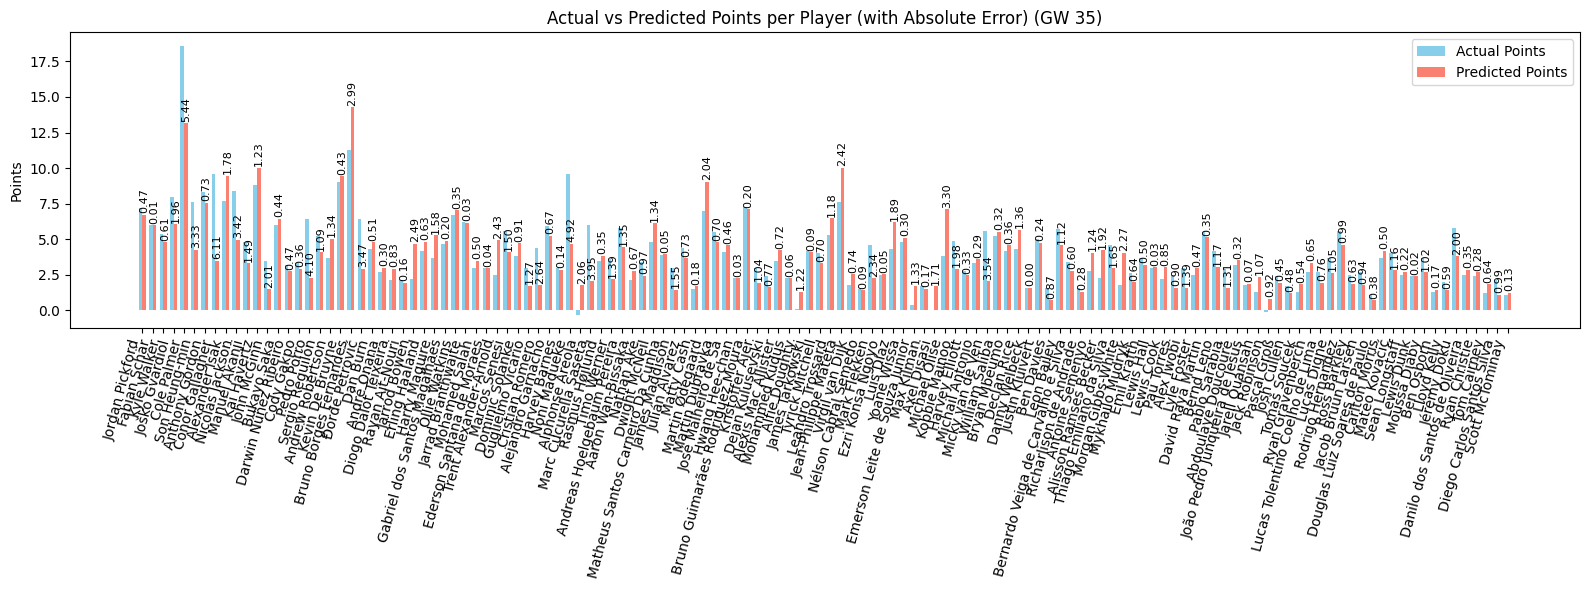

In [112]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred_35, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 35)")
plt.legend()
plt.tight_layout()

plt.show()

# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred_35, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 35)")
plt.legend()

plt.tight_layout()
plt.show()

# Calculate absolute errors
errors = np.abs(Y_test - Y_pred_35)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred_35, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred_35[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error) (GW 35)")
plt.legend()
plt.tight_layout()

plt.show()

#### Optimize


In [113]:
curr_data = final_df[final_df['round'] == 35].copy()
curr_data['xP_pred'] = Y_pred_35

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected_35 = run_pipeline(players)

# Get total points
players_selected_35 = curr_data[curr_data['fpl_id'].isin(selected_35['fpl_id'])].copy()
# players_selected_35 = players_selected_35.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_35['xp_rank'] = players_selected_35['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_35['xp_rank'] == 1,  # Highest xp_preds
    players_selected_35['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_35['score'] = players_selected_35['score'] * np.select(conditions, multipliers, default=1.0)
total_points_35 = sum(players_selected_35['score'].values)
print(total_points_35, players_selected_35['score'].values, '--------->', players_selected_35['xP_pred'].values)

players_selected_35[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-278.6482
IRL epoch 100/200 loss=-2981.2578
IRL epoch 150/200 loss=-12615.7168
IRL epoch 200/200 loss=-34451.4102


HGAT Policy Embeddings Shape: torch.Size([132, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                      name               team position  price    xP_pred  \
19         Kevin De Bruyne    Manchester City      MID   10.4   9.433681   
54         Martin Ødegaard            Arsenal      MID    8.6   9.036135   
20  Bruno Borges Fernandes  Manchester United      MID    8.4  14.292278   
11             Kai Havertz            Arsenal      MID    7.4  10.028795   
4              Cole Palmer            Chelsea      MID    6.2  13.160473   
0          Jordan Pickford            Everton       GK    4.7   6.731432   
8           Alexander Isak   Newcastle United      FWD    8.2   9.475749   
67    Jean-Philippe Mateta     Crystal Palace      FWD    5.1  10.021138   
1             Fabian Schär   Newcastle United      DEF    5.7   5.986482   
3           Joško Gvardiol    Manchester City      DEF    4.9   6.035973   
31      Jarrad Branthwaite            Everton      DEF    4.3   

,fpl_name,team,position,xP_pred,score
4389,Jordan Pickford,Everton,GK,6.731432,10.0
4390,Fabian Schär,Newcastle United,DEF,5.986482,1.0
4392,Joško Gvardiol,Manchester City,DEF,6.035973,15.0
4393,Cole Palmer,Chelsea,MID,13.160473,12.0
4397,Alexander Isak,Newcastle United,FWD,9.475749,13.0
4400,Kai Havertz,Arsenal,MID,10.028795,13.0
4408,Kevin De Bruyne,Manchester City,MID,9.433681,11.0
4409,Bruno Borges Fernandes,Manchester United,MID,14.292278,8.0
4420,Jarrad Branthwaite,Everton,DEF,6.165487,6.0
4443,Martin Ødegaard,Arsenal,MID,9.036135,2.0


##### Rank


In [114]:
fg_managers_35 = fg_managers[fg_managers['gameweek'] == 35]
fg_managers_35[['points']]

position = (fg_managers_35['points'] > total_points_35).sum() + 1
# 4. Display result
total_managers = len(fg_managers_35)
percentile = 100 * (1-(position / total_managers))

print(total_points_35, total_managers)

print(f"Your predicted player’s total of {total_points_35} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers_35.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

93.0 0
Your predicted player’s total of 93.0 points would rank:
→ Position: 1 out of 0 managers
→ Percentile: Top -inf%

Closest scores around you:
Empty DataFrame
Columns: [points, prize]
Index: []


/tmp/ipython-input-1259483589.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  percentile = 100 * (1-(position / total_managers))


### GW 36


#### Predict


Data prepared. X shape: (4926, 177), M shape: (4926, 3), Y shape: (4926, 2)

Starting Training...
Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 11.8456 - mae: 2.7241 - mse: 11.6095 - val_loss: 4.2842 - val_mae: 1.4525 - val_mse: 4.0473
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3.9306 - mae: 1.4377 - mse: 3.6937 - val_loss: 3.2478 - val_mae: 1.2418 - val_mse: 3.0109
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.9354 - mae: 1.2088 - mse: 2.6986 - val_loss: 2.8848 - val_mae: 1.1565 - val_mse: 2.6480
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.5451 - mae: 1.1062 - mse: 2.3085 - val_loss: 2.7534 - val_mae: 1.1210 - val_mse: 2.5169
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 2.2778 - mae: 1.0348 - mse: 2.0413 - val_loss: 2.6563 - val_mae: 1.1014 - val_mse: 2.4200
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 2.1884 - mae: 1.0187 - mse: 1.9522 - val_loss: 2.6745 - val_mae: 1.1034 - val_mse: 2.4385

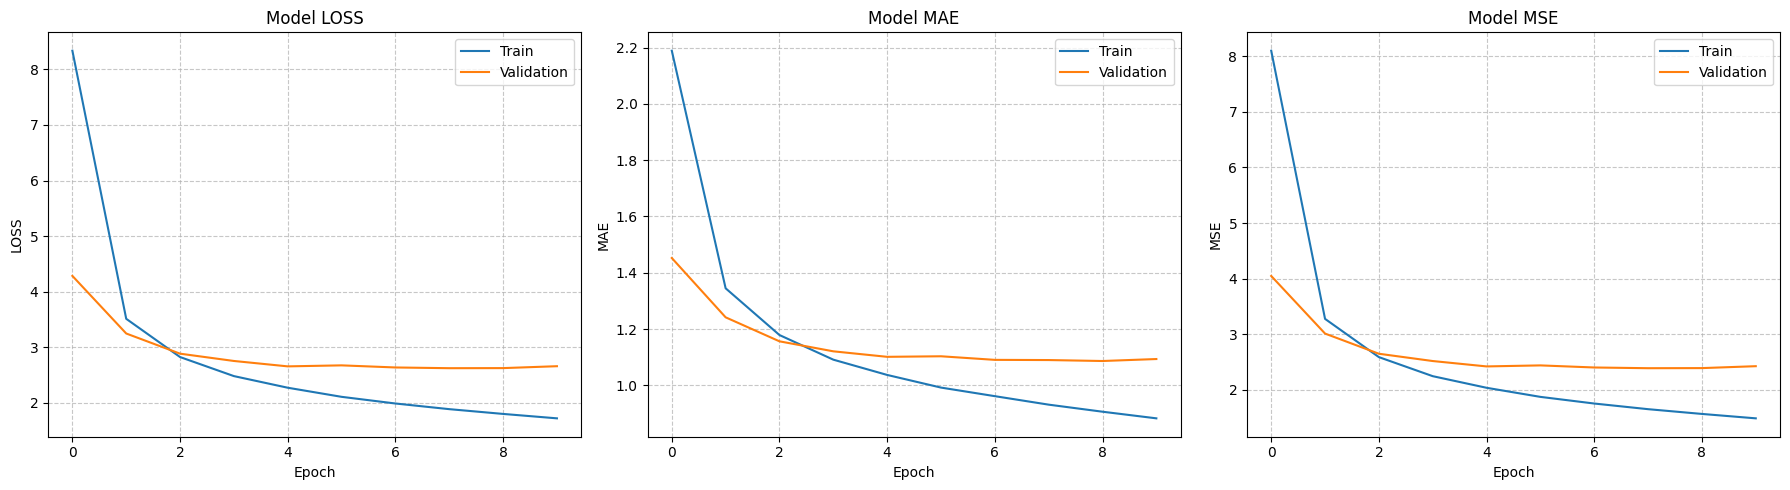


--- Final Test Set Evaluation (GW 36) ---

Evaluating test set performance...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Evaluating test set performance...{'loss': 1.6723463535308838, 'mae': 0.9594168066978455, 'mse': 1.441753625869751}
R²: 0.6176624157413726
MAE: 1.0600951910018921
MSE: 2.0075798034667969
Loss: 2.2431194782257080

Generating Predictions...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

--- Results for Gameweek 36 ---
 Gameweek          Player  Actual_xP  Predicted_xP  Team_Diff  Opp_Diff
       36     Cole Palmer        8.4         14.89       0.59      1.23
       36  Erling Haaland       10.0         11.43       1.52     -2.14
       36      Phil Foden        6.2          9.95       1.52     -2.14
       36  Alexander Isak        9.0          9.88       0.22     -0.16
       36    Noni Madueke        6.6          9.31       0.59     -0.62
       36 Nicolas Jackson        8.0          9.30       0.59     -0.62
       36 Kevin De Bruyne        7.0          8.54       1.52     -2.

In [115]:
train_data, test_data , GW_full, X_cols = transform_data(final_df, cols, 36)
X_train_scaled, M_train_scaled, train_mask, Y_train, _ = train_data
X_test_scaled, M_test_scaled, test_mask, Y_test, Y_test_names = test_data

# Model Setup
INPUT_DIM_X = X_train_scaled.shape[1]
INPUT_DIM_M = M_train_scaled.shape[1]
OUTPUT_DIM_Y = 1

model_36 = build_affine_pnn(INPUT_DIM_X, INPUT_DIM_M, OUTPUT_DIM_Y)
model_36.compile(optimizer=Adam(learning_rate=0.0001, clipnorm=1.0), loss='mse', metrics=['mae', 'mse'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Training
print("\nStarting Training...")
history_36 = model_36.fit(
    [X_train_scaled, M_train_scaled], Y_train,
    epochs=10, # Increased epochs with early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Plot History
plot_training_history(history_36)

# EVALUATE TEST SET PERFORMANCE
print("\n--- Final Test Set Evaluation (GW 36) ---")
test_result_36 = model_36.evaluate([X_test_scaled, M_test_scaled], Y_test, return_dict=True, verbose=0)

evaluation_metrics = evaluator(model_36, X_test_scaled, M_test_scaled, Y_test)
print(f"Evaluating test set performance...{test_result_31}")
print(f"R²: {evaluation_metrics['test_R2']:.16f}")
print(f"MAE: {evaluation_metrics['test_mae']:.16f}")
print(f"MSE: {evaluation_metrics['test_mse']:.16f}")
print(f"Loss: {evaluation_metrics['test_loss']:.16f}")


# Prediction
print("\nGenerating Predictions...")
Y_pred_36 = model_36.predict([X_test_scaled, M_test_scaled]).flatten()

# Results
results_df_36 = pd.DataFrame({
    'Gameweek': GW_full[test_mask],
    'Player': Y_test_names,
    'Actual_xP': Y_test,
    'Predicted_xP': Y_pred_36,
    'Team_Diff': M_test_scaled[:, 1],
    'Opp_Diff': M_test_scaled[:, 0]
})

print("\n--- Results for Gameweek 36 ---")
print(results_df_36.sort_values(by='Predicted_xP', ascending=False).head(10).round(2).to_string(index=False))

##### Plots


ValueError: x and y must have same first dimension, but have shapes (142,) and (132,)

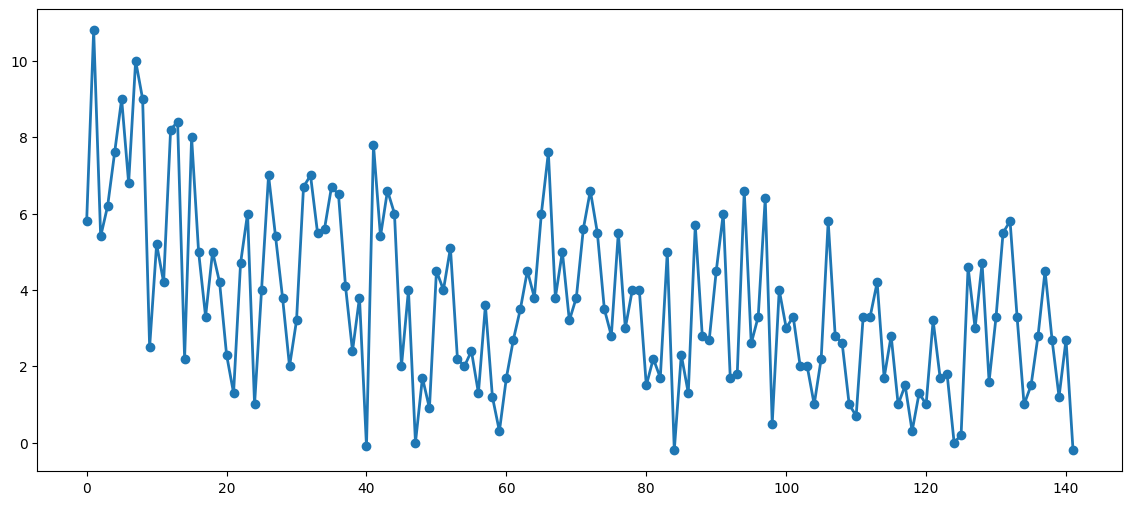

In [116]:
# Convert names to positions on x-axis
x = np.arange(len(Y_test_names))

plt.figure(figsize=(14, 6))

# Plot actual points
plt.plot(x, Y_test, marker='o', linewidth=2, label='Actual Points')

# Plot predicted points
plt.plot(x, Y_pred_35, marker='x', linewidth=2, label='Predicted Points')

# Improve readability
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 35)")
plt.legend()
plt.tight_layout()

plt.show()

# Index positions for players
x = np.arange(len(Y_test_names))

# Width of each bar
width = 0.35

plt.figure(figsize=(14, 6))

# Bars
plt.bar(x - width/2, Y_test, width, label='Actual Points')
plt.bar(x + width/2, Y_pred_35, width, label='Predicted Points')

# Labels & formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.xlabel("Players")
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (GW 35)")
plt.legend()

plt.tight_layout()
plt.show()

# Calculate absolute errors
errors = np.abs(Y_test - Y_pred_35)

# Index for players
x = np.arange(len(Y_test_names))
width = 0.35  # width of the bars

plt.figure(figsize=(16, 6))

# Plot Actual and Predicted points side-by-side
plt.bar(x - width/2, Y_test, width, label='Actual Points', color='skyblue')
plt.bar(x + width/2, Y_pred_35, width, label='Predicted Points', color='salmon')

# Annotate absolute errors on top of predicted bars
for i in range(len(Y_test_names)):
    plt.text(x[i] + width/2, Y_pred_35[i] + 0.1, f"{errors[i]:.2f}", ha='center', va='bottom', fontsize=8, rotation=90)

# Labels and formatting
plt.xticks(x, Y_test_names, rotation=75, ha='right')
plt.ylabel("Points")
plt.title("Actual vs Predicted Points per Player (with Absolute Error) (GW 35)")
plt.legend()
plt.tight_layout()

plt.show()

#### Optimize


In [ ]:
curr_data = final_df[final_df['round'] == 35].copy()
curr_data['xP_pred'] = Y_pred_35

players = curr_data[['fpl_id', 'fpl_name', 'team', 'value', 'position', 'xP_pred']].copy()
players['player_id'] = list(range(len(players)))

players.rename(columns={'fpl_name': 'name', 'value': 'price'}, inplace=True)
players = players.reset_index(drop=True)

selected_35 = run_pipeline(players)

# Get total points
players_selected_35 = curr_data[curr_data['fpl_id'].isin(selected_35['fpl_id'])].copy()
# players_selected_35 = players_selected_35.copy()
# 1. Create the rank column based on 'xp_preds'
# method='dense' ensures ties get the same rank, and the next rank is sequential
players_selected_35['xp_rank'] = players_selected_35['xP_pred'].rank(method='dense', ascending=False).astype(int)

# 2. Define the conditions and their corresponding multipliers
conditions = [
    players_selected_35['xp_rank'] == 1,  # Highest xp_preds
    players_selected_35['xp_rank'] == 2   # Second highest xp_preds
]
multipliers = [2.0, 1.5] # [multiplier for rank 1, multiplier for rank 2]

# 3. Use np.select() to apply the multiplier
# The 'default=1.0' means any rank other than 1 or 2 gets a 1.0 multiplier
players_selected_35['score'] = players_selected_35['score'] * np.select(conditions, multipliers, default=1.0)
total_points_35 = sum(players_selected_35['score'].values)
print(total_points_35, players_selected_35['score'].values, '--------->', players_selected_35['xP_pred'].values)

players_selected_35[['fpl_name', 'team', 'position', 'xP_pred', 'score']]

Expert selected count (11-man heuristic): 11
IRL epoch 50/200 loss=-306.3610
IRL epoch 100/200 loss=-3519.5039
IRL epoch 150/200 loss=-15204.5176
IRL epoch 200/200 loss=-41875.7812
HGAT Policy Embeddings Shape: torch.Size([134, 32])

--- OPTIMAL FPL TEAM (IRL-HGAT-ILP RESULT) ---
                      name               team position  price    xP_pred  \
58         Kevin De Bruyne    Manchester City      MID   10.4   8.587764   
18  Bruno Borges Fernandes  Manchester United      MID    8.3  11.421783   
24              Phil Foden    Manchester City      MID    8.2   9.662992   
7              Kai Havertz            Arsenal      MID    7.4   7.242973   
86          Anthony Gordon   Newcastle United      MID    6.1   8.671877   
73            Mark Flekken          Brentford       GK    4.7   5.342443   
47          Alexander Isak   Newcastle United      FWD    8.0   6.480964   
9     Jean-Philippe Mateta     Crystal Palace      FWD    5.0   5.764374   
92            Fabian Schär   Newcas

,fpl_name,team,position,xP_pred,score
4262,Kai Havertz,Arsenal,MID,7.242973,17.0
4264,Jean-Philippe Mateta,Crystal Palace,FWD,5.764374,29.0
4273,Bruno Borges Fernandes,Manchester United,MID,11.421783,36.0
4279,Phil Foden,Manchester City,MID,9.662992,24.0
4283,Sergio Reguilón,Manchester United,DEF,5.408250,7.0
4302,Alexander Isak,Newcastle United,FWD,6.480964,2.0
4313,Kevin De Bruyne,Manchester City,MID,8.587764,9.0
4328,Mark Flekken,Brentford,GK,5.342443,2.0
4335,Joško Gvardiol,Manchester City,DEF,5.673817,6.0
4341,Anthony Gordon,Newcastle United,MID,8.671877,1.0


##### Rank


In [ ]:
fg_managers_35 = fg_managers[fg_managers['gameweek'] == 35]
fg_managers_35[['points']]

position = (fg_managers_35['points'] > total_points_35).sum() + 1
# 4. Display result
total_managers = len(fg_managers_35)
percentile = 100 * (1-(position / total_managers))

print(total_points_35, total_managers)

print(f"Your predicted player’s total of {total_points_35} points would rank:")
print(f"→ Position: {position} out of {total_managers} managers")
print(f"→ Percentile: Top {percentile:.2f}%")


# Optional: show nearby ranks for context
nearby = fg_managers_35.iloc[max(position-15,0):position+2][['points','prize']].reset_index(drop=True)
print("\nClosest scores around you:")
print(nearby)

134.0 203
Your predicted player’s total of 134.0 points would rank:
→ Position: 52 out of 203 managers
→ Percentile: Top 74.38%

Closest scores around you:
    points    prize
0    138.0  R 26.76
1    137.5  R 26.76
2    137.5  R 26.76
3    137.5  R 26.76
4    137.5  R 26.76
5    137.5  R 26.76
6    136.5  R 26.76
7    136.5  R 26.76
8    136.5  R 26.76
9    135.5  R 26.76
10   135.5  R 26.76
11   135.0  R 26.76
12   134.5  R 26.76
13   134.5  R 26.76
14   133.5      NaN
15   132.5      NaN
16   132.0      NaN
